# AutoShield — Insurance Data Cleaning & Fraud Model Preparation

## Project Objective

This notebook performs data profiling, quality assessment, cleaning,
validation, feature engineering, and machine-learning preprocessing
for the AutoShield Insurance Analytics project.

The raw insurance data is stored in MySQL across five relational tables:

- Customers
- Vehicles
- Policies
- Claims
- Payments

The cleaned data will later be used for:

1. Insurance claims analytics
2. Streamlit dashboard development
3. Power BI reporting
4. Fraud claim prediction

## Important Principle

The original raw data in MySQL will not be modified.

All cleaning and preprocessing will be performed in Python, producing
cleaned datasets for downstream analytics and machine learning.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine

import os
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [4]:
# Project root
BASE_DIR = Path.cwd().resolve().parent

# Load environment variables
load_dotenv(BASE_DIR / ".env")

DB_HOST = os.getenv("DB_HOST")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

required_vars = {
    "DB_HOST": DB_HOST,
    "DB_USER": DB_USER,
    "DB_PASSWORD": DB_PASSWORD,
    "DB_NAME": DB_NAME
}

missing_vars = [
    name for name, value in required_vars.items()
    if not value
]

if missing_vars:
    raise EnvironmentError(
        f"Missing environment variables: {', '.join(missing_vars)}"
    )

print("Environment variables loaded successfully.")
print(f"Database: {DB_NAME}")
print(f"Host: {DB_HOST}")
print(f"User: {DB_USER}")

Environment variables loaded successfully.
Database: autoshield_insurance
Host: localhost
User: root


Create MySQL connection

In [5]:
DATABASE_URL = (
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}/{DB_NAME}"
)

engine = create_engine(DATABASE_URL)

print("MySQL connection engine created successfully.")

MySQL connection engine created successfully.


In [6]:
with engine.connect() as connection:
    print("Connected to MySQL successfully.")

Connected to MySQL successfully.


Load all five tables

In [7]:
customers = pd.read_sql("SELECT * FROM customers", engine)
vehicles = pd.read_sql("SELECT * FROM vehicles", engine)
policies = pd.read_sql("SELECT * FROM policies", engine)
claims = pd.read_sql("SELECT * FROM claims", engine)
payments = pd.read_sql("SELECT * FROM payments", engine)

In [8]:
print("Customers :", customers.shape)
print("Vehicles  :", vehicles.shape)
print("Policies  :", policies.shape)
print("Claims    :", claims.shape)
print("Payments  :", payments.shape)

Customers : (1000, 13)
Vehicles  : (1200, 11)
Policies  : (1500, 10)
Claims    : (3000, 15)
Payments  : (2238, 6)


## 1. Initial Dataset Overview

Before performing any cleaning, the structure and size of each
dataset are examined to establish a baseline.

In [9]:
dataset_summary = pd.DataFrame({
    "Table": [
        "Customers",
        "Vehicles",
        "Policies",
        "Claims",
        "Payments"
    ],
    "Rows": [
        len(customers),
        len(vehicles),
        len(policies),
        len(claims),
        len(payments)
    ],
    "Columns": [
        customers.shape[1],
        vehicles.shape[1],
        policies.shape[1],
        claims.shape[1],
        payments.shape[1]
    ]
})

dataset_summary

,Table,Rows,Columns
0,Customers,1000,13
1,Vehicles,1200,11
2,Policies,1500,10
3,Claims,3000,15
4,Payments,2238,6


Inspect the columns

In [10]:
for name, df in {
    "Customers": customers,
    "Vehicles": vehicles,
    "Policies": policies,
    "Claims": claims,
    "Payments": payments
}.items():

    print("=" * 70)
    print(name)
    print("=" * 70)
    print(df.columns.tolist())
    print()

Customers
['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Marital_Status', 'Occupation', 'Annual_Income', 'City', 'State', 'Address', 'Contact_Number', 'Email', 'Driving_Experience_Years']

Vehicles
['Vehicle_ID', 'Customer_ID', 'Vehicle_Type', 'Brand', 'Model', 'Manufacture_Year', 'Registration_State', 'Fuel_Type', 'Engine_CC', 'Vehicle_Value', 'Purchase_Date']

Policies
['Policy_ID', 'Customer_ID', 'Vehicle_ID', 'Policy_Type', 'Coverage_Amount', 'Premium_Amount', 'Start_Date', 'End_Date', 'No_Claim_Bonus', 'Policy_Status']

Claims
['Claim_ID', 'Policy_ID', 'Vehicle_ID', 'Customer_ID', 'Claim_Date', 'Accident_City', 'Accident_Type', 'Weather_Condition', 'Police_Report_Filed', 'Injuries', 'Estimated_Damage_Cost', 'Claim_Amount', 'Fraud_Suspected', 'Claim_Status', 'Settlement_Days']

Payments
['Payment_ID', 'Claim_ID', 'Payment_Date', 'Payment_Mode', 'Amount_Paid', 'Payment_Status']



## 2. Data Type Profiling

Data types are examined before cleaning because incorrect data types
can affect calculations, comparisons, date operations, and machine
learning preprocessing.

In [11]:
for name, df in {
    "Customers": customers,
    "Vehicles": vehicles,
    "Policies": policies,
    "Claims": claims,
    "Payments": payments
}.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    display(
        pd.DataFrame({
            "Column": df.columns,
            "Data_Type": df.dtypes.astype(str).values,
            "Missing_Values": df.isna().sum().values,
            "Unique_Values": df.nunique().values
        })
    )

Customers


,Column,Data_Type,Missing_Values,Unique_Values
0,Customer_ID,str,0,1000
1,Customer_Name,str,0,149
2,Gender,str,0,2
3,Age,int64,0,58
4,Marital_Status,str,0,2
5,Occupation,str,0,6
6,Annual_Income,float64,0,1000
7,City,str,0,12
8,State,str,0,10
9,Address,str,0,999


Vehicles


,Column,Data_Type,Missing_Values,Unique_Values
0,Vehicle_ID,str,0,1200
1,Customer_ID,str,0,717
2,Vehicle_Type,str,0,4
3,Brand,str,0,8
4,Model,str,0,8
5,Manufacture_Year,int64,0,15
6,Registration_State,str,0,10
7,Fuel_Type,str,0,5
8,Engine_CC,int64,0,5
9,Vehicle_Value,float64,0,1200


Policies


,Column,Data_Type,Missing_Values,Unique_Values
0,Policy_ID,str,0,1500
1,Customer_ID,str,0,583
2,Vehicle_ID,str,0,842
3,Policy_Type,str,0,3
4,Coverage_Amount,float64,0,1499
5,Premium_Amount,float64,0,1481
6,Start_Date,object,0,1076
7,End_Date,object,0,1076
8,No_Claim_Bonus,int64,0,6
9,Policy_Status,str,0,3


Claims


,Column,Data_Type,Missing_Values,Unique_Values
0,Claim_ID,str,0,3000
1,Policy_ID,str,0,1308
2,Vehicle_ID,str,0,783
3,Customer_ID,str,0,549
4,Claim_Date,object,0,1710
5,Accident_City,str,0,12
6,Accident_Type,str,0,6
7,Weather_Condition,str,0,5
8,Police_Report_Filed,str,0,2
9,Injuries,str,979,2


Payments


,Column,Data_Type,Missing_Values,Unique_Values
0,Payment_ID,str,0,2238
1,Claim_ID,str,0,2238
2,Payment_Date,object,0,1433
3,Payment_Mode,str,0,5
4,Amount_Paid,float64,0,2237
5,Payment_Status,str,0,3


Missing-value audit

In [12]:
def missing_value_report(df, table_name):

    report = pd.DataFrame({
        "Column": df.columns,
        "Missing_Count": df.isna().sum().values,
        "Missing_Percentage": (
            df.isna().mean().values * 100
        )
    })

    report = report[
        report["Missing_Count"] > 0
    ].sort_values(
        "Missing_Count",
        ascending=False
    )

    print(f"\n{table_name}")

    if report.empty:
        print("No missing values found.")
    else:
        display(report)


missing_value_report(customers, "Customers")
missing_value_report(vehicles, "Vehicles")
missing_value_report(policies, "Policies")
missing_value_report(claims, "Claims")
missing_value_report(payments, "Payments")


Customers
No missing values found.

Vehicles
No missing values found.

Policies
No missing values found.

Claims


,Column,Missing_Count,Missing_Percentage
9,Injuries,979,32.63



Payments
No missing values found.


Investigate Injuries

In [13]:
claims["Injuries"].value_counts(dropna=False)

Injuries
Minor      1041
Serious     980
NaN         979
Name: count, dtype: int64

Duplicate audit in Python

In [14]:
datasets = {
    "Customers": customers,
    "Vehicles": vehicles,
    "Policies": policies,
    "Claims": claims,
    "Payments": payments
}

duplicate_summary = []

for name, df in datasets.items():

    duplicate_summary.append({
        "Table": name,
        "Duplicate_Rows": df.duplicated().sum(),
        "Rows": len(df)
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

duplicate_summary

,Table,Duplicate_Rows,Rows
0,Customers,0,1000
1,Vehicles,0,1200
2,Policies,0,1500
3,Claims,0,3000
4,Payments,0,2238


Primary key Uniqueness

In [15]:
primary_keys = {
    "Customers": ("Customer_ID", customers),
    "Vehicles": ("Vehicle_ID", vehicles),
    "Policies": ("Policy_ID", policies),
    "Claims": ("Claim_ID", claims),
    "Payments": ("Payment_ID", payments)
}

for table_name, (key, df) in primary_keys.items():

    duplicate_keys = df[key].duplicated().sum()

    print(
        f"{table_name}: "
        f"{duplicate_keys} duplicate {key} values"
    )

Customers: 0 duplicate Customer_ID values
Vehicles: 0 duplicate Vehicle_ID values
Policies: 0 duplicate Policy_ID values
Claims: 0 duplicate Claim_ID values
Payments: 0 duplicate Payment_ID values


Business validation checks

In [16]:
invalid_policy_dates = policies[
    policies["End_Date"] < policies["Start_Date"]
]

print(
    f"Policies with End_Date before Start_Date: "
    f"{len(invalid_policy_dates)}"
)

Policies with End_Date before Start_Date: 0


In [17]:
invalid_claim_amounts = claims[
    claims["Claim_Amount"] > claims["Estimated_Damage_Cost"]
]

print(
    f"Claims exceeding estimated damage cost: "
    f"{len(invalid_claim_amounts)}"
)

Claims exceeding estimated damage cost: 0


In [18]:
payment_claim_check = payments.merge(
    claims[["Claim_ID", "Claim_Date"]],
    on="Claim_ID",
    how="left"
)

invalid_payment_dates = payment_claim_check[
    payment_claim_check["Payment_Date"]
    < payment_claim_check["Claim_Date"]
]

print(
    f"Payments before claim date: "
    f"{len(invalid_payment_dates)}"
)

Payments before claim date: 0


## 3. Missing Value Treatment — Injuries

The `Injuries` column contains 979 missing values out of 3,000 claims.

The observed values are:

- Minor: 1,041
- Serious: 980
- Missing: 979

Because injury severity cannot be reliably determined from the available
raw data, missing values will not be imputed as either Minor or Serious.

Instead, missing values will be represented as `Unknown`.

This approach preserves the distinction between:
- Known Minor injuries
- Known Serious injuries
- Unrecorded injury information

The original raw MySQL data remains unchanged.

In [19]:
# Check missing values before treatment
print("Missing Injuries before cleaning:")
print(claims["Injuries"].isna().sum())

Missing Injuries before cleaning:
979


In [20]:
claims["Injuries"] = claims["Injuries"].fillna("Unknown")

In [21]:
claims["Injuries"].value_counts(dropna=False)

Injuries
Minor      1041
Serious     980
Unknown     979
Name: count, dtype: int64

In [22]:
print(
    "Missing Injuries after cleaning:",
    claims["Injuries"].isna().sum()
)

Missing Injuries after cleaning: 0


In [23]:
categorical_columns = {
    "Customers": [
        "Gender",
        "Marital_Status",
        "Occupation",
        "State"
    ],
    "Vehicles": [
        "Vehicle_Type",
        "Brand",
        "Registration_State",
        "Fuel_Type"
    ],
    "Policies": [
        "Policy_Type",
        "Policy_Status"
    ],
    "Claims": [
        "Accident_Type",
        "Weather_Condition",
        "Police_Report_Filed",
        "Injuries",
        "Fraud_Suspected",
        "Claim_Status"
    ],
    "Payments": [
        "Payment_Mode",
        "Payment_Status"
    ]
}

for table_name, columns in categorical_columns.items():

    df = datasets[table_name]

    print("\n" + "=" * 70)
    print(table_name)
    print("=" * 70)

    for column in columns:
        print('\n')
        print(df[column].value_counts(dropna=False))


Customers


Gender
Female    510
Male      490
Name: count, dtype: int64


Marital_Status
Single     500
Married    500
Name: count, dtype: int64


Occupation
Teacher     178
Business    178
Engineer    169
Doctor      167
Govt        164
Student     144
Name: count, dtype: int64


State
Uttar Pradesh    182
Maharashtra      148
Gujarat          107
Rajasthan         87
Tamil Nadu        87
Telangana         87
Haryana           85
West Bengal       76
Delhi             71
Karnataka         70
Name: count, dtype: int64

Vehicles


Vehicle_Type
Sedan         323
Motorcycle    304
SUV           297
Hatchback     276
Name: count, dtype: int64


Brand
Kia         165
Hyundai     163
Mahindra    154
Maruti      149
BMW         148
Tata        148
Toyota      137
Honda       136
Name: count, dtype: int64


Registration_State
Telangana        147
Karnataka        139
Haryana          130
Rajasthan        126
Tamil Nadu       126
Uttar Pradesh    118
Gujarat          114
Maharashtra      102


## 4. Numerical Data Validation

Numerical fields are examined for invalid, negative, zero, or potentially
unrealistic values. Statistical summaries are used to identify potential
data-quality issues before applying any cleaning rules.

In [24]:
numerical_columns = {
    "Customers": [
        "Age",
        "Annual_Income",
        "Driving_Experience_Years"
    ],
    
    "Vehicles": [
        "Manufacture_Year",
        "Engine_CC",
        "Vehicle_Value"
    ],
    
    "Policies": [
        "Coverage_Amount",
        "Premium_Amount",
        "No_Claim_Bonus"
    ],
    
    "Claims": [
        "Estimated_Damage_Cost",
        "Claim_Amount",
        "Settlement_Days"
    ],
    
    "Payments": [
        "Amount_Paid"
    ]
}

for table_name, columns in numerical_columns.items():
    
    print("\n" + "=" * 70)
    print(table_name)
    print("=" * 70)
    
    display(
        datasets[table_name][columns].describe().T
    )


Customers


,count,mean,std,min,25%,50%,75%,max
Age,"1,000.00",47.11,16.88,18.00,32.00,48.00,62.00,75.00
Annual_Income,"1,000.00","2,608,335.98","1,366,950.35","200,717.00","1,416,624.25","2,585,935.50","3,818,961.00","4,999,856.00"
Driving_Experience_Years,"1,000.00",15.08,13.68,0.00,4.00,11.00,23.00,57.00



Vehicles


,count,mean,std,min,25%,50%,75%,max
Manufacture_Year,"1,200.00","2,018.88",4.33,"2,012.00","2,015.00","2,019.00","2,023.00","2,026.00"
Engine_CC,"1,200.00","1,289.17",418.30,800.00,"1,000.00","1,200.00","1,500.00","2,000.00"
Vehicle_Value,"1,200.00","4,212,872.66","2,303,104.55","150,716.00","2,202,945.00","4,299,271.00","6,219,450.00","7,998,016.00"



Policies


,count,mean,std,min,25%,50%,75%,max
Coverage_Amount,"1,500.00","5,110,461.08","2,841,786.08","219,707.00","2,635,165.00","5,022,530.00","7,620,349.25","9,998,082.00"
Premium_Amount,"1,500.00","41,672.19","22,352.15","3,007.00","22,904.00","42,380.50","60,985.50","79,996.00"
No_Claim_Bonus,"1,500.00",28.99,16.62,0.00,20.00,35.00,45.00,50.00



Claims


,count,mean,std,min,25%,50%,75%,max
Estimated_Damage_Cost,"3,000.00","1,145,965.21","728,853.96","14,897.00","492,414.25","1,074,036.50","1,776,071.50","2,541,428.00"
Claim_Amount,"3,000.00","1,120,818.54","728,943.89","5,293.00","471,120.25","1,046,412.00","1,750,336.75","2,499,137.00"
Settlement_Days,"3,000.00",91.15,52.72,2.00,44.75,90.00,137.00,180.00



Payments


,count,mean,std,min,25%,50%,75%,max
Amount_Paid,"2,238.00","833,579.91","573,563.10","3,752.00","345,566.25","757,219.00","1,249,808.75","2,474,833.00"


Check negative values

In [25]:
for table_name, columns in numerical_columns.items():
    
    df = datasets[table_name]
    
    print("\n" + "=" * 70)
    print(table_name)
    print("=" * 70)
    
    for column in columns:
        
        negative_count = (df[column] < 0).sum()
        
        print(
            f"{column}: {negative_count} negative values"
        )


Customers
Age: 0 negative values
Annual_Income: 0 negative values
Driving_Experience_Years: 0 negative values

Vehicles
Manufacture_Year: 0 negative values
Engine_CC: 0 negative values
Vehicle_Value: 0 negative values

Policies
Coverage_Amount: 0 negative values
Premium_Amount: 0 negative values
No_Claim_Bonus: 0 negative values

Claims
Estimated_Damage_Cost: 0 negative values
Claim_Amount: 0 negative values
Settlement_Days: 0 negative values

Payments
Amount_Paid: 0 negative values


Check zero values

In [26]:
for table_name, columns in numerical_columns.items():
    
    df = datasets[table_name]
    
    print("\n" + "=" * 70)
    print(table_name)
    print("=" * 70)
    
    for column in columns:
        
        zero_count = (df[column] == 0).sum()
        
        print(
            f"{column}: {zero_count} zero values"
        )


Customers
Age: 0 zero values
Annual_Income: 0 zero values
Driving_Experience_Years: 72 zero values

Vehicles
Manufacture_Year: 0 zero values
Engine_CC: 0 zero values
Vehicle_Value: 0 zero values

Policies
Coverage_Amount: 0 zero values
Premium_Amount: 0 zero values
No_Claim_Bonus: 253 zero values

Claims
Estimated_Damage_Cost: 0 zero values
Claim_Amount: 0 zero values
Settlement_Days: 0 zero values

Payments
Amount_Paid: 0 zero values


customer-specific validation

In [27]:
invalid_age = customers[
    (customers["Age"] < 18) |
    (customers["Age"] > 100)
]

print(f"Invalid customer ages: {len(invalid_age)}")

Invalid customer ages: 0


In [28]:
invalid_experience = customers[
    (customers["Driving_Experience_Years"] < 0) |
    (customers["Driving_Experience_Years"] > customers["Age"] - 18)
]

print(
    f"Potentially invalid driving experience: "
    f"{len(invalid_experience)}"
)

Potentially invalid driving experience: 0


Vehicle Validation

In [29]:
invalid_manufacture_year = vehicles[
    (vehicles["Manufacture_Year"] < 1900) |
    (vehicles["Manufacture_Year"] > 2026)
]

print(
    f"Invalid manufacture years: "
    f"{len(invalid_manufacture_year)}"
)

Invalid manufacture years: 0


In [30]:
invalid_engine = vehicles[
    vehicles["Engine_CC"] <= 0
]

print(
    f"Invalid engine capacities: "
    f"{len(invalid_engine)}"
)

Invalid engine capacities: 0


In [31]:
invalid_vehicle_value = vehicles[
    vehicles["Vehicle_Value"] <= 0
]

print(
    f"Invalid vehicle values: "
    f"{len(invalid_vehicle_value)}"
)

Invalid vehicle values: 0


Policy validation

In [32]:
invalid_coverage = policies[
    policies["Coverage_Amount"] <= 0
]

print(
    f"Invalid coverage amounts: "
    f"{len(invalid_coverage)}"
)

Invalid coverage amounts: 0


In [33]:
invalid_premium = policies[
    policies["Premium_Amount"] <= 0
]

print(
    f"Invalid premium amounts: "
    f"{len(invalid_premium)}"
)

Invalid premium amounts: 0


In [34]:
invalid_ncb = policies[
    (policies["No_Claim_Bonus"] < 0) |
    (policies["No_Claim_Bonus"] > 100)
]

print(
    f"Invalid No-Claim Bonus values: "
    f"{len(invalid_ncb)}"
)

Invalid No-Claim Bonus values: 0


Claims validation

In [35]:
invalid_damage = claims[
    claims["Estimated_Damage_Cost"] < 0
]

print(
    f"Invalid damage costs: "
    f"{len(invalid_damage)}"
)

Invalid damage costs: 0


In [36]:
invalid_claim_amount = claims[
    claims["Claim_Amount"] < 0
]

print(
    f"Invalid claim amounts: "
    f"{len(invalid_claim_amount)}"
)

Invalid claim amounts: 0


In [37]:
invalid_settlement = claims[
    claims["Settlement_Days"] < 0
]

print(
    f"Invalid settlement days: "
    f"{len(invalid_settlement)}"
)

Invalid settlement days: 0


In [38]:
claim_exceeds_damage = claims[
    claims["Claim_Amount"] > claims["Estimated_Damage_Cost"]
]

print(
    f"Claims exceeding estimated damage: "
    f"{len(claim_exceeds_damage)}"
)

Claims exceeding estimated damage: 0


Payment validation

In [39]:
invalid_payment = payments[
    payments["Amount_Paid"] < 0
]

print(
    f"Invalid payment amounts: "
    f"{len(invalid_payment)}"
)

Invalid payment amounts: 0


Premium vs coverage relationship

In [40]:
policies["Premium_Coverage_Ratio"] = (
    policies["Premium_Amount"] /
    policies["Coverage_Amount"]
)

In [41]:
policies["Premium_Coverage_Ratio"].describe()

count   1,500.00
mean        0.02
std         0.03
min         0.00
25%         0.00
50%         0.01
75%         0.02
max         0.32
Name: Premium_Coverage_Ratio, dtype: float64

In [42]:
policies[
    policies["Premium_Coverage_Ratio"] > 1
][[
    "Policy_ID",
    "Coverage_Amount",
    "Premium_Amount",
    "Premium_Coverage_Ratio"
]]

,Policy_ID,Coverage_Amount,Premium_Amount,Premium_Coverage_Ratio


Claim severity ratio

In [43]:
claims["Claim_Damage_Ratio"] = (
    claims["Claim_Amount"] /
    claims["Estimated_Damage_Cost"]
)

In [44]:
claims["Claim_Damage_Ratio"].describe()

count   3,000.00
mean        0.95
std         0.10
min         0.12
25%         0.95
50%         0.98
75%         0.99
max         1.00
Name: Claim_Damage_Ratio, dtype: float64

In [45]:
claims[
    claims["Claim_Damage_Ratio"] > 1
][[
    "Claim_ID",
    "Claim_Amount",
    "Estimated_Damage_Cost",
    "Claim_Damage_Ratio"
]]

,Claim_ID,Claim_Amount,Estimated_Damage_Cost,Claim_Damage_Ratio


## 5. Date and Cross-Table Validation

Insurance events occur across multiple related tables. Date validation
is therefore performed both within individual tables and across
relationships between customers, vehicles, policies, claims, and payments.

The objective is to identify records that violate the expected business
timeline or contain inconsistent relationships.

In [46]:
date_columns = {
    "Vehicles": ["Purchase_Date"],
    "Policies": ["Start_Date", "End_Date"],
    "Claims": ["Claim_Date"],
    "Payments": ["Payment_Date"]
}

for table_name, columns in date_columns.items():
    
    print("\n" + "=" * 60)
    print(table_name)
    print("=" * 60)
    
    for column in columns:
        print(
            f"{column}: {datasets[table_name][column].dtype}"
        )


Vehicles
Purchase_Date: object

Policies
Start_Date: object
End_Date: object

Claims
Claim_Date: object

Payments
Payment_Date: object


In [47]:
for table_name, columns in date_columns.items():
    
    df = datasets[table_name]
    
    for column in columns:
        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )

In [48]:
for table_name, columns in date_columns.items():
    
    df = datasets[table_name]
    
    for column in columns:
        print(
            f"{table_name}.{column}: "
            f"{df[column].dtype}"
        )

Vehicles.Purchase_Date: datetime64[s]
Policies.Start_Date: datetime64[s]
Policies.End_Date: datetime64[s]
Claims.Claim_Date: datetime64[s]
Payments.Payment_Date: datetime64[s]


In [49]:
for table_name, columns in date_columns.items():
    
    df = datasets[table_name]
    
    for column in columns:
        
        invalid_dates = df[column].isna().sum()
        
        print(
            f"{table_name}.{column}: "
            f"{invalid_dates} invalid/missing dates"
        )

Vehicles.Purchase_Date: 0 invalid/missing dates
Policies.Start_Date: 0 invalid/missing dates
Policies.End_Date: 0 invalid/missing dates
Claims.Claim_Date: 0 invalid/missing dates
Payments.Payment_Date: 0 invalid/missing dates


In [50]:
invalid_policy_dates = policies[
    policies["End_Date"] < policies["Start_Date"]
]

print(
    "Policies with End_Date before Start_Date:",
    len(invalid_policy_dates)
)

Policies with End_Date before Start_Date: 0


In [51]:
print("Earliest policy start:", policies["Start_Date"].min())
print("Latest policy start:", policies["Start_Date"].max())

print("Earliest policy end:", policies["End_Date"].min())
print("Latest policy end:", policies["End_Date"].max())

Earliest policy start: 2020-01-01 00:00:00
Latest policy start: 2025-12-31 00:00:00
Earliest policy end: 2020-12-31 00:00:00
Latest policy end: 2026-12-31 00:00:00


In [52]:
vehicles["Purchase_Year"] = (
    vehicles["Purchase_Date"].dt.year
)

invalid_vehicle_dates = vehicles[
    vehicles["Purchase_Year"] < vehicles["Manufacture_Year"]
]

print(
    "Vehicles purchased before manufacture:",
    len(invalid_vehicle_dates)
)

Vehicles purchased before manufacture: 0


In [53]:
policy_vehicle_check = policies.merge(
    vehicles[
        [
            "Vehicle_ID",
            "Purchase_Date"
        ]
    ],
    on="Vehicle_ID",
    how="left"
)

invalid_policy_vehicle_dates = policy_vehicle_check[
    policy_vehicle_check["Start_Date"]
    < policy_vehicle_check["Purchase_Date"]
]

print(
    "Policies starting before vehicle purchase:",
    len(invalid_policy_vehicle_dates)
)

Policies starting before vehicle purchase: 821


In [54]:
claim_policy_check = claims.merge(
    policies[
        [
            "Policy_ID",
            "Start_Date",
            "End_Date"
        ]
    ],
    on="Policy_ID",
    how="left"
)

invalid_claim_policy_dates = claim_policy_check[
    (claim_policy_check["Claim_Date"] < claim_policy_check["Start_Date"]) |
    (claim_policy_check["Claim_Date"] > claim_policy_check["End_Date"])
]

print(
    "Claims outside policy period:",
    len(invalid_claim_policy_dates)
)

Claims outside policy period: 0


In [55]:
payment_claim_check = payments.merge(
    claims[
        [
            "Claim_ID",
            "Claim_Date"
        ]
    ],
    on="Claim_ID",
    how="left"
)

invalid_payment_dates = payment_claim_check[
    payment_claim_check["Payment_Date"]
    < payment_claim_check["Claim_Date"]
]

print(
    "Payments before claim date:",
    len(invalid_payment_dates)
)

Payments before claim date: 0


In [56]:
policy_customer_check = policies.merge(
    vehicles[
        [
            "Vehicle_ID",
            "Customer_ID"
        ]
    ],
    on="Vehicle_ID",
    how="left",
    suffixes=("_Policy", "_Vehicle")
)

inconsistent_policy_customers = policy_customer_check[
    policy_customer_check["Customer_ID_Policy"]
    != policy_customer_check["Customer_ID_Vehicle"]
]

print(
    "Policies with customer/vehicle mismatch:",
    len(inconsistent_policy_customers)
)

Policies with customer/vehicle mismatch: 0


In [57]:
claim_policy_customer = claims.merge(
    policies[
        [
            "Policy_ID",
            "Customer_ID"
        ]
    ],
    on="Policy_ID",
    how="left",
    suffixes=("_Claim", "_Policy")
)

claim_policy_mismatch = claim_policy_customer[
    claim_policy_customer["Customer_ID_Claim"]
    != claim_policy_customer["Customer_ID_Policy"]
]

print(
    "Claims with claim/policy customer mismatch:",
    len(claim_policy_mismatch)
)

Claims with claim/policy customer mismatch: 0


In [58]:
claim_vehicle_customer = claims.merge(
    vehicles[
        [
            "Vehicle_ID",
            "Customer_ID"
        ]
    ],
    on="Vehicle_ID",
    how="left",
    suffixes=("_Claim", "_Vehicle")
)

claim_vehicle_mismatch = claim_vehicle_customer[
    claim_vehicle_customer["Customer_ID_Claim"]
    != claim_vehicle_customer["Customer_ID_Vehicle"]
]

print(
    "Claims with claim/vehicle customer mismatch:",
    len(claim_vehicle_mismatch)
)

Claims with claim/vehicle customer mismatch: 0


In [59]:
claim_policy_vehicle = claims.merge(
    policies[
        [
            "Policy_ID",
            "Vehicle_ID"
        ]
    ],
    on="Policy_ID",
    how="left",
    suffixes=("_Claim", "_Policy")
)

claim_vehicle_mismatch = claim_policy_vehicle[
    claim_policy_vehicle["Vehicle_ID_Claim"]
    != claim_policy_vehicle["Vehicle_ID_Policy"]
]

print(
    "Claims with policy/vehicle mismatch:",
    len(claim_vehicle_mismatch)
)

Claims with policy/vehicle mismatch: 0


In [60]:
payment_claim_exists = payments.merge(
    claims[["Claim_ID"]],
    on="Claim_ID",
    how="left",
    indicator=True
)

missing_claims_for_payments = payment_claim_exists[
    payment_claim_exists["_merge"] == "left_only"
]

print(
    "Payments without matching claims:",
    len(missing_claims_for_payments)
)

Payments without matching claims: 0


Investigating the 821 records where policices start before vehicle purchase

In [61]:
invalid_policy_vehicle_dates[
    [
        "Policy_ID",
        "Vehicle_ID",
        "Customer_ID",
        "Start_Date",
        "Purchase_Date"
    ]
].head(20)

,Policy_ID,Vehicle_ID,Customer_ID,Start_Date,Purchase_Date
0,POL_000001,VEH_0673,CUST_0313,2023-04-30,2026-04-21
1,POL_000002,VEH_0717,CUST_0720,2021-01-31,2026-11-29
2,POL_000003,VEH_1007,CUST_0233,2021-02-22,2025-04-05
3,POL_000004,VEH_1045,CUST_0265,2021-04-06,2024-01-05
7,POL_000008,VEH_0230,CUST_0960,2022-08-05,2025-08-03
8,POL_000009,VEH_0787,CUST_0764,2025-06-15,2026-11-08
9,POL_000010,VEH_0392,CUST_0532,2020-11-18,2024-09-14
10,POL_000011,VEH_1064,CUST_0024,2021-04-10,2026-11-09
12,POL_000013,VEH_1008,CUST_0954,2022-12-18,2026-05-03
15,POL_000016,VEH_0010,CUST_0063,2020-03-24,2023-07-27


In [62]:
invalid_policy_vehicle_dates = invalid_policy_vehicle_dates.copy()

invalid_policy_vehicle_dates["Days_Before_Purchase"] = (
    invalid_policy_vehicle_dates["Purchase_Date"]
    - invalid_policy_vehicle_dates["Start_Date"]
).dt.days

invalid_policy_vehicle_dates["Days_Before_Purchase"].describe()

count     821.00
mean      955.76
std       618.69
min         5.00
25%       441.00
50%       855.00
75%     1,432.00
max     2,482.00
Name: Days_Before_Purchase, dtype: float64

In [63]:
invalid_policy_vehicle_dates[
    "Days_Before_Purchase"
].value_counts().sort_index().head(20)

Days_Before_Purchase
5     1
6     1
8     1
12    1
13    1
15    1
16    2
18    1
19    1
21    1
22    2
24    1
26    2
33    1
34    1
36    1
37    1
45    1
46    1
47    1
Name: count, dtype: int64

In [64]:
print(
    "Minimum days between purchase and policy start:",
    invalid_policy_vehicle_dates["Days_Before_Purchase"].min()
)

print(
    "Maximum days between purchase and policy start:",
    invalid_policy_vehicle_dates["Days_Before_Purchase"].max()
)

Minimum days between purchase and policy start: 5
Maximum days between purchase and policy start: 2482


In [65]:
policy_vehicle_issue_pct = (
    len(invalid_policy_vehicle_dates)
    / len(policies)
) * 100

print(
    f"Policies starting before vehicle purchase: "
    f"{len(invalid_policy_vehicle_dates):,}"
)

print(
    f"Percentage of policies affected: "
    f"{policy_vehicle_issue_pct:.2f}%"
)

Policies starting before vehicle purchase: 821
Percentage of policies affected: 54.73%


In [66]:
invalid_policy_vehicle_dates["Policy_Type"].value_counts()

Policy_Type
Comprehensive        294
Zero Depreciation    265
Third Party          262
Name: count, dtype: int64

In [67]:
invalid_policy_vehicle_dates["Policy_Status"].value_counts()

Policy_Status
Expired      308
Cancelled    284
Active       229
Name: count, dtype: int64

In [68]:
pd.crosstab(
    invalid_policy_vehicle_dates["Policy_Type"],
    invalid_policy_vehicle_dates["Policy_Status"]
)

Policy_Status,Active,Cancelled,Expired
Policy_Type,,,
Comprehensive,90,109,95
Third Party,76,81,105
Zero Depreciation,63,94,108


In [69]:
vehicles_original = vehicles.copy()
policies_original = policies.copy()

In [70]:
earliest_policy = (
    policies
    .groupby("Vehicle_ID")["Start_Date"]
    .min()
    .reset_index()
)

earliest_policy.head()

,Vehicle_ID,Start_Date
0,VEH_0001,2023-08-20
1,VEH_0002,2020-08-07
2,VEH_0003,2020-08-02
3,VEH_0004,2023-05-09
4,VEH_0005,2020-09-24


In [71]:
vehicle_date_check = vehicles.merge(
    earliest_policy,
    on="Vehicle_ID",
    how="left"
)

vehicle_date_check.rename(
    columns={
        "Start_Date": "Earliest_Policy_Start"
    },
    inplace=True
)

In [72]:
vehicle_date_check[
    [
        "Vehicle_ID",
        "Manufacture_Year",
        "Purchase_Date",
        "Earliest_Policy_Start"
    ]
].head(10)

,Vehicle_ID,Manufacture_Year,Purchase_Date,Earliest_Policy_Start
0,VEH_0001,2013,2017-04-09,2023-08-20
1,VEH_0002,2012,2015-10-13,2020-08-07
2,VEH_0003,2025,2025-04-07,2020-08-02
3,VEH_0004,2016,2025-04-30,2023-05-09
4,VEH_0005,2023,2025-10-20,2020-09-24
5,VEH_0006,2026,2026-10-29,2025-08-23
6,VEH_0007,2020,2023-10-25,2022-09-29
7,VEH_0008,2013,2024-07-23,2020-06-21
8,VEH_0009,2019,2019-04-04,2024-12-02
9,VEH_0010,2018,2023-07-27,2020-03-24


In [73]:
vehicle_date_check["Needs_Correction"] = (
    vehicle_date_check["Purchase_Date"]
    > vehicle_date_check["Earliest_Policy_Start"]
)

In [74]:
print(
    "Vehicles requiring correction:",
    vehicle_date_check["Needs_Correction"].sum()
)

Vehicles requiring correction: 514


In [75]:
vehicle_date_check["Proposed_Purchase_Date"] = (
    vehicle_date_check["Earliest_Policy_Start"]
    - pd.Timedelta(days=30)
)

In [76]:
vehicle_date_check["Proposed_Manufacture_Year"] = (
    vehicle_date_check["Manufacture_Year"]
)

In [77]:
manufacture_conflict = (
    vehicle_date_check["Manufacture_Year"]
    >
    vehicle_date_check["Proposed_Purchase_Date"].dt.year
)

vehicle_date_check.loc[
    manufacture_conflict,
    "Proposed_Manufacture_Year"
] = (
    vehicle_date_check.loc[
        manufacture_conflict,
        "Proposed_Purchase_Date"
    ].dt.year
)

In [78]:
proposed_changes = vehicle_date_check[
    vehicle_date_check["Needs_Correction"]
][
    [
        "Vehicle_ID",
        "Manufacture_Year",
        "Purchase_Date",
        "Earliest_Policy_Start",
        "Proposed_Manufacture_Year",
        "Proposed_Purchase_Date"
    ]
]

proposed_changes.head(20)

,Vehicle_ID,Manufacture_Year,Purchase_Date,Earliest_Policy_Start,Proposed_Manufacture_Year,Proposed_Purchase_Date
2,VEH_0003,2025,2025-04-07,2020-08-02,2020,2020-07-03
3,VEH_0004,2016,2025-04-30,2023-05-09,2016,2023-04-09
4,VEH_0005,2023,2025-10-20,2020-09-24,2020,2020-08-25
5,VEH_0006,2026,2026-10-29,2025-08-23,2025,2025-07-24
6,VEH_0007,2020,2023-10-25,2022-09-29,2020,2022-08-30
7,VEH_0008,2013,2024-07-23,2020-06-21,2013,2020-05-22
9,VEH_0010,2018,2023-07-27,2020-03-24,2018,2020-02-23
13,VEH_0014,2018,2023-02-14,2020-12-28,2018,2020-11-28
15,VEH_0016,2015,2024-09-18,2021-05-22,2015,2021-04-22
16,VEH_0017,2021,2026-09-29,2023-07-27,2021,2023-06-27


In [79]:
print(
    "Vehicles requiring manufacture-year correction:",
    manufacture_conflict.sum()
)

Vehicles requiring manufacture-year correction: 235


In [80]:
print(
    "Vehicles requiring purchase-date correction:",
    vehicle_date_check["Needs_Correction"].sum()
)

Vehicles requiring purchase-date correction: 514


In [81]:
proposed_invalid = vehicle_date_check[
    (
        vehicle_date_check["Proposed_Purchase_Date"]
        >
        vehicle_date_check["Earliest_Policy_Start"]
    )
    |
    (
        vehicle_date_check["Proposed_Manufacture_Year"]
        >
        vehicle_date_check["Proposed_Purchase_Date"].dt.year
    )
]

print(
    "Vehicles still violating date chronology:",
    len(proposed_invalid)
)

Vehicles still violating date chronology: 0


In [82]:
# Keep the original values for audit purposes
vehicles["Original_Manufacture_Year"] = vehicles["Manufacture_Year"]
vehicles["Original_Purchase_Date"] = vehicles["Purchase_Date"]

# Apply corrected manufacture year
vehicles.loc[
    vehicle_date_check["Needs_Correction"],
    "Manufacture_Year"
] = vehicle_date_check.loc[
    vehicle_date_check["Needs_Correction"],
    "Proposed_Manufacture_Year"
]

# Apply corrected purchase date
vehicles.loc[
    vehicle_date_check["Needs_Correction"],
    "Purchase_Date"
] = vehicle_date_check.loc[
    vehicle_date_check["Needs_Correction"],
    "Proposed_Purchase_Date"
]

In [83]:
policy_vehicle_check = policies.merge(
    vehicles[
        ["Vehicle_ID", "Purchase_Date"]
    ],
    on="Vehicle_ID",
    how="left"
)

invalid_policy_vehicle_dates = policy_vehicle_check[
    policy_vehicle_check["Start_Date"]
    < policy_vehicle_check["Purchase_Date"]
]

print(
    "Policies starting before vehicle purchase:",
    len(invalid_policy_vehicle_dates)
)

Policies starting before vehicle purchase: 0


In [84]:
invalid_manufacture_purchase = vehicles[
    pd.to_datetime(
        vehicles["Purchase_Date"]
    ).dt.year
    < vehicles["Manufacture_Year"]
]

print(
    "Vehicles purchased before manufacture:",
    len(invalid_manufacture_purchase)
)

Vehicles purchased before manufacture: 0


In [85]:
print(
    "Manufacture years changed:",
    (
        vehicles["Manufacture_Year"]
        != vehicles["Original_Manufacture_Year"]
    ).sum()
)

print(
    "Purchase dates changed:",
    (
        vehicles["Purchase_Date"]
        != vehicles["Original_Purchase_Date"]
    ).sum()
)

Manufacture years changed: 235
Purchase dates changed: 514


In [86]:
# Recheck policy start date vs corrected vehicle purchase date

policy_vehicle_check = policies.merge(
    vehicles[
        ["Vehicle_ID", "Purchase_Date"]
    ],
    on="Vehicle_ID",
    how="left"
)

invalid_policy_vehicle_dates = policy_vehicle_check[
    policy_vehicle_check["Start_Date"]
    < policy_vehicle_check["Purchase_Date"]
]

print(
    "Policies starting before vehicle purchase:",
    len(invalid_policy_vehicle_dates)
)

Policies starting before vehicle purchase: 0


In [87]:
print("Original violations: 821")
print("Remaining violations:", len(invalid_policy_vehicle_dates))
print(
    "Violations corrected:",
    821 - len(invalid_policy_vehicle_dates)
)

Original violations: 821
Remaining violations: 0
Violations corrected: 821


In [88]:
invalid_manufacture_purchase = vehicles[
    pd.to_datetime(vehicles["Purchase_Date"]).dt.year
    < vehicles["Manufacture_Year"]
]

print(
    "Vehicles purchased before manufacture:",
    len(invalid_manufacture_purchase)
)

Vehicles purchased before manufacture: 0


## 6. Fraud Prediction Dataset Preparation

The claims table is enriched with customer, vehicle, and policy
information to create a modeling dataset.

The target variable is `Fraud_Suspected`.

Features that represent post-investigation or post-settlement information,
as well as database identifiers, are excluded to reduce data leakage.

Feature engineering is performed only from information that could
reasonably be available when evaluating a claim.

In [89]:
print("Claims:", claims.shape)
print("Customers:", customers.shape)
print("Vehicles:", vehicles.shape)
print("Policies:", policies.shape)

Claims: (3000, 16)
Customers: (1000, 13)
Vehicles: (1200, 14)
Policies: (1500, 11)


In [90]:
fraud_model_df = claims.copy()

In [91]:
customer_features = customers[
    [
        "Customer_ID",
        "Gender",
        "Age",
        "Marital_Status",
        "Occupation",
        "Annual_Income",
        "Driving_Experience_Years"
    ]
].copy()

In [92]:
fraud_model_df = fraud_model_df.merge(
    customer_features,
    on="Customer_ID",
    how="left"
)

In [93]:
vehicle_features = vehicles[
    [
        "Vehicle_ID",
        "Vehicle_Type",
        "Brand",
        "Manufacture_Year",
        "Fuel_Type",
        "Engine_CC",
        "Vehicle_Value"
    ]
].copy()

In [94]:
fraud_model_df = fraud_model_df.merge(
    vehicle_features,
    on="Vehicle_ID",
    how="left"
)

In [95]:
policy_features = policies[
    [
        "Policy_ID",
        "Policy_Type",
        "Coverage_Amount",
        "Premium_Amount",
        "No_Claim_Bonus"
    ]
].copy()

In [96]:
fraud_model_df = fraud_model_df.merge(
    policy_features,
    on="Policy_ID",
    how="left"
)

In [97]:
print("Fraud modeling dataset shape:", fraud_model_df.shape)
print("Unique claims:", fraud_model_df["Claim_ID"].nunique())

Fraud modeling dataset shape: (3000, 32)
Unique claims: 3000


In [98]:
assert len(fraud_model_df) == len(claims)
assert fraud_model_df["Claim_ID"].nunique() == len(claims)

print("One-row-per-claim validation passed.")

One-row-per-claim validation passed.


In [99]:
join_columns = [
    "Gender",
    "Vehicle_Type",
    "Policy_Type"
]

for column in join_columns:
    print(
        f"{column} missing after join:",
        fraud_model_df[column].isna().sum()
    )

Gender missing after join: 0
Vehicle_Type missing after join: 0
Policy_Type missing after join: 0


Vehicle age at the time of claim

In [100]:
fraud_model_df["Vehicle_Age"] = (
    fraud_model_df["Claim_Date"].dt.year
    - fraud_model_df["Manufacture_Year"]
)

In [101]:
fraud_model_df["Vehicle_Age"].describe()

count   3,000.00
mean        5.03
std         3.68
min         0.00
25%         2.00
50%         5.00
75%         8.00
max        14.00
Name: Vehicle_Age, dtype: float64

In [102]:
fraud_model_df["Premium_Coverage_Ratio"] = (
    fraud_model_df["Premium_Amount"]
    / fraud_model_df["Coverage_Amount"]
)

In [103]:
fraud_model_df["Claim_Damage_Ratio"] = (
    fraud_model_df["Claim_Amount"]
    / fraud_model_df["Estimated_Damage_Cost"]
)

In [104]:
fraud_model_df["Claim_Vehicle_Value_Ratio"] = (
    fraud_model_df["Claim_Amount"]
    / fraud_model_df["Vehicle_Value"]
)

In [105]:
fraud_model_df[
    [
        "Vehicle_Age",
        "Premium_Coverage_Ratio",
        "Claim_Damage_Ratio",
        "Claim_Vehicle_Value_Ratio"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Vehicle_Age,"3,000.00",5.03,3.68,0.00,2.00,5.00,8.00,14.00
Premium_Coverage_Ratio,"3,000.00",0.02,0.03,0.00,0.00,0.01,0.02,0.32
Claim_Damage_Ratio,"3,000.00",0.95,0.10,0.12,0.95,0.98,0.99,1.00
Claim_Vehicle_Value_Ratio,"3,000.00",0.59,1.13,0.00,0.11,0.26,0.54,14.97


In [106]:
engineered_features = [
    "Vehicle_Age",
    "Premium_Coverage_Ratio",
    "Claim_Damage_Ratio",
    "Claim_Vehicle_Value_Ratio"
]

for column in engineered_features:
    print(
        f"{column}:",
        "negative =", (fraud_model_df[column] < 0).sum(),
        "| missing =", fraud_model_df[column].isna().sum()
    )

Vehicle_Age: negative = 0 | missing = 0
Premium_Coverage_Ratio: negative = 0 | missing = 0
Claim_Damage_Ratio: negative = 0 | missing = 0
Claim_Vehicle_Value_Ratio: negative = 0 | missing = 0


In [107]:
fraud_model_df["Fraud_Target"] = (
    fraud_model_df["Fraud_Suspected"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

In [108]:
fraud_model_df["Fraud_Target"].value_counts()

Fraud_Target
0    1536
1    1464
Name: count, dtype: int64

In [109]:
print(
    "Missing target values:",
    fraud_model_df["Fraud_Target"].isna().sum()
)

Missing target values: 0


In [110]:
drop_columns = [
    "Customer_ID",
    "Vehicle_ID",
    "Policy_ID",
    "Claim_ID",
    "Fraud_Suspected",
    "Claim_Status",
    "Settlement_Days"
]

In [111]:
model_features_df = fraud_model_df.drop(
    columns=drop_columns
)

In [112]:
print("Model dataset shape:", model_features_df.shape)
print(model_features_df.columns.tolist())

Model dataset shape: (3000, 29)
['Claim_Date', 'Accident_City', 'Accident_Type', 'Weather_Condition', 'Police_Report_Filed', 'Injuries', 'Estimated_Damage_Cost', 'Claim_Amount', 'Claim_Damage_Ratio', 'Gender', 'Age', 'Marital_Status', 'Occupation', 'Annual_Income', 'Driving_Experience_Years', 'Vehicle_Type', 'Brand', 'Manufacture_Year', 'Fuel_Type', 'Engine_CC', 'Vehicle_Value', 'Policy_Type', 'Coverage_Amount', 'Premium_Amount', 'No_Claim_Bonus', 'Vehicle_Age', 'Premium_Coverage_Ratio', 'Claim_Vehicle_Value_Ratio', 'Fraud_Target']


In [113]:
X = model_features_df.drop(
    columns=["Fraud_Target"]
)

y = model_features_df["Fraud_Target"]

In [114]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (3000, 28)
Target: (3000,)


In [115]:
print("\nFeature columns:")
for column in X.columns:
    print("-", column)


Feature columns:
- Claim_Date
- Accident_City
- Accident_Type
- Weather_Condition
- Police_Report_Filed
- Injuries
- Estimated_Damage_Cost
- Claim_Amount
- Claim_Damage_Ratio
- Gender
- Age
- Marital_Status
- Occupation
- Annual_Income
- Driving_Experience_Years
- Vehicle_Type
- Brand
- Manufacture_Year
- Fuel_Type
- Engine_CC
- Vehicle_Value
- Policy_Type
- Coverage_Amount
- Premium_Amount
- No_Claim_Bonus
- Vehicle_Age
- Premium_Coverage_Ratio
- Claim_Vehicle_Value_Ratio


## 7. Final Feature Engineering

Additional temporal features are extracted from the claim date.

Raw identifiers and post-claim outcome variables are excluded from the
machine-learning feature set.

The resulting dataset is separated into predictors (`X`) and the target
variable (`y`) before the train/test split.

In [116]:
# Extract useful temporal information from Claim_Date

fraud_model_df["Claim_Year"] = (
    fraud_model_df["Claim_Date"].dt.year
)

fraud_model_df["Claim_Month"] = (
    fraud_model_df["Claim_Date"].dt.month
)

fraud_model_df["Claim_DayOfWeek"] = (
    fraud_model_df["Claim_Date"].dt.dayofweek
)

In [117]:
fraud_model_df["Claim_Weekend"] = (
    fraud_model_df["Claim_DayOfWeek"] >= 5
).astype(int)

In [118]:
fraud_model_df[
    [
        "Claim_Date",
        "Claim_Year",
        "Claim_Month",
        "Claim_DayOfWeek",
        "Claim_Weekend"
    ]
].head()

,Claim_Date,Claim_Year,Claim_Month,Claim_DayOfWeek,Claim_Weekend
0,2020-10-18,2020,10,6,1
1,2023-02-28,2023,2,1,0
2,2023-07-28,2023,7,4,0
3,2021-01-22,2021,1,4,0
4,2020-10-29,2020,10,3,0


In [119]:
fraud_model_df.drop(
    columns=["Claim_Date"],
    inplace=True
)

In [120]:
feature_columns = [
    # Customer
    "Gender",
    "Age",
    "Marital_Status",
    "Occupation",
    "Annual_Income",
    "Driving_Experience_Years",

    # Vehicle
    "Vehicle_Type",
    "Brand",
    "Manufacture_Year",
    "Fuel_Type",
    "Engine_CC",
    "Vehicle_Value",

    # Policy
    "Policy_Type",
    "Coverage_Amount",
    "Premium_Amount",
    "No_Claim_Bonus",

    # Claim
    "Accident_City",
    "Accident_Type",
    "Weather_Condition",
    "Police_Report_Filed",
    "Injuries",
    "Estimated_Damage_Cost",
    "Claim_Amount",

    # Engineered
    "Vehicle_Age",
    "Premium_Coverage_Ratio",
    "Claim_Damage_Ratio",
    "Claim_Vehicle_Value_Ratio",

    # Temporal
    "Claim_Year",
    "Claim_Month",
    "Claim_DayOfWeek",
    "Claim_Weekend"
]

In [121]:
model_df = fraud_model_df[
    feature_columns + ["Fraud_Target"]
].copy()

In [122]:
print("Final modeling dataset:", model_df.shape)

Final modeling dataset: (3000, 32)


In [123]:
missing_model_values = (
    model_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_model_values[
    missing_model_values > 0
]

Series([], dtype: int64)

In [124]:
print(
    "Total missing values:",
    model_df.isna().sum().sum()
)

Total missing values: 0


In [125]:
model_df["Fraud_Target"].value_counts()

Fraud_Target
0    1536
1    1464
Name: count, dtype: int64

In [126]:
model_df["Fraud_Target"].value_counts(
    normalize=True
).mul(100).round(2)

Fraud_Target
0   51.20
1   48.80
Name: proportion, dtype: float64

In [127]:
X = model_df.drop(
    columns=["Fraud_Target"]
)

y = model_df["Fraud_Target"]

In [128]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 31)
y shape: (3000,)


In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [130]:
print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (2400, 31)
Testing features : (600, 31)
Training target  : (2400,)
Testing target   : (600,)


In [131]:
print("Overall fraud rate:")
print(y.mean())

print("\nTraining fraud rate:")
print(y_train.mean())

print("\nTesting fraud rate:")
print(y_test.mean())

Overall fraud rate:
0.488

Training fraud rate:
0.48791666666666667

Testing fraud rate:
0.48833333333333334


In [132]:
numeric_features = [
    "Age",
    "Annual_Income",
    "Driving_Experience_Years",
    "Manufacture_Year",
    "Engine_CC",
    "Vehicle_Value",
    "Coverage_Amount",
    "Premium_Amount",
    "No_Claim_Bonus",
    "Estimated_Damage_Cost",
    "Claim_Amount",
    "Vehicle_Age",
    "Premium_Coverage_Ratio",
    "Claim_Damage_Ratio",
    "Claim_Vehicle_Value_Ratio",
    "Claim_Year",
    "Claim_Month",
    "Claim_DayOfWeek",
    "Claim_Weekend"
]

In [133]:
categorical_features = [
    "Gender",
    "Marital_Status",
    "Occupation",
    "Vehicle_Type",
    "Brand",
    "Fuel_Type",
    "Policy_Type",
    "Accident_City",
    "Accident_Type",
    "Weather_Condition",
    "Police_Report_Filed",
    "Injuries"
]

In [134]:
print(
    "Total features:",
    len(numeric_features) + len(categorical_features)
)

print(
    "Actual X columns:",
    len(X.columns)
)

Total features: 31
Actual X columns: 31


In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [136]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [137]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [138]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

In [139]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [140]:
print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (2400, 77)
Processed testing shape: (600, 77)


In [141]:
print(
    "Processed data type:",
    type(X_train_processed)
)

Processed data type: <class 'numpy.ndarray'>


In [142]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Number of processed features:",
    len(feature_names)
)

Number of processed features: 77


In [143]:
feature_names

array(['num__Age', 'num__Annual_Income', 'num__Driving_Experience_Years',
       'num__Manufacture_Year', 'num__Engine_CC', 'num__Vehicle_Value',
       'num__Coverage_Amount', 'num__Premium_Amount',
       'num__No_Claim_Bonus', 'num__Estimated_Damage_Cost',
       'num__Claim_Amount', 'num__Vehicle_Age',
       'num__Premium_Coverage_Ratio', 'num__Claim_Damage_Ratio',
       'num__Claim_Vehicle_Value_Ratio', 'num__Claim_Year',
       'num__Claim_Month', 'num__Claim_DayOfWeek', 'num__Claim_Weekend',
       'cat__Gender_Female', 'cat__Gender_Male',
       'cat__Marital_Status_Married', 'cat__Marital_Status_Single',
       'cat__Occupation_Business', 'cat__Occupation_Doctor',
       'cat__Occupation_Engineer', 'cat__Occupation_Govt',
       'cat__Occupation_Student', 'cat__Occupation_Teacher',
       'cat__Vehicle_Type_Hatchback', 'cat__Vehicle_Type_Motorcycle',
       'cat__Vehicle_Type_SUV', 'cat__Vehicle_Type_Sedan',
       'cat__Brand_BMW', 'cat__Brand_Honda', 'cat__Brand_Hyundai',


In [144]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [145]:
X_train_processed_df.head()

,num__Age,num__Annual_Income,num__Driving_Experience_Years,num__Manufacture_Year,num__Engine_CC,num__Vehicle_Value,num__Coverage_Amount,num__Premium_Amount,num__No_Claim_Bonus,num__Estimated_Damage_Cost,num__Claim_Amount,num__Vehicle_Age,num__Premium_Coverage_Ratio,num__Claim_Damage_Ratio,num__Claim_Vehicle_Value_Ratio,num__Claim_Year,num__Claim_Month,num__Claim_DayOfWeek,num__Claim_Weekend,cat__Gender_Female,cat__Gender_Male,cat__Marital_Status_Married,cat__Marital_Status_Single,cat__Occupation_Business,cat__Occupation_Doctor,cat__Occupation_Engineer,cat__Occupation_Govt,cat__Occupation_Student,cat__Occupation_Teacher,cat__Vehicle_Type_Hatchback,cat__Vehicle_Type_Motorcycle,cat__Vehicle_Type_SUV,cat__Vehicle_Type_Sedan,cat__Brand_BMW,cat__Brand_Honda,cat__Brand_Hyundai,cat__Brand_Kia,cat__Brand_Mahindra,cat__Brand_Maruti,cat__Brand_Tata,cat__Brand_Toyota,cat__Fuel_Type_CNG,cat__Fuel_Type_Diesel,cat__Fuel_Type_Electric,cat__Fuel_Type_Hybrid,cat__Fuel_Type_Petrol,cat__Policy_Type_Comprehensive,cat__Policy_Type_Third Party,cat__Policy_Type_Zero Depreciation,cat__Accident_City_Ahmedabad,cat__Accident_City_Bengaluru,cat__Accident_City_Chennai,cat__Accident_City_Delhi,cat__Accident_City_Gurugram,cat__Accident_City_Hyderabad,cat__Accident_City_Jaipur,cat__Accident_City_Kolkata,cat__Accident_City_Lucknow,cat__Accident_City_Mumbai,cat__Accident_City_Noida,cat__Accident_City_Pune,cat__Accident_Type_Collision,cat__Accident_Type_Fire,cat__Accident_Type_Flood,cat__Accident_Type_Major Accident,cat__Accident_Type_Minor Accident,cat__Accident_Type_Theft,cat__Weather_Condition_Cloudy,cat__Weather_Condition_Fog,cat__Weather_Condition_Rainy,cat__Weather_Condition_Storm,cat__Weather_Condition_Sunny,cat__Police_Report_Filed_No,cat__Police_Report_Filed_Yes,cat__Injuries_Minor,cat__Injuries_Serious,cat__Injuries_Unknown
369,-1.10,0.00,-0.48,0.86,-0.69,-0.84,1.01,-0.47,0.39,0.21,0.18,0.00,-0.46,0.16,-0.02,1.68,-1.34,-1.03,-0.63,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
1043,0.90,0.62,0.23,0.57,0.52,-0.31,0.89,0.81,-0.49,0.84,0.85,-0.27,-0.32,0.43,-0.07,0.55,-0.16,0.49,-0.63,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00
946,-1.28,-1.46,-0.70,-1.17,-1.18,0.59,-1.38,1.57,0.98,-0.31,-0.30,1.35,1.96,0.41,-0.38,0.55,1.31,-1.54,-0.63,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00
2212,-0.93,-0.27,-1.06,-0.59,0.52,0.87,1.05,0.24,0.39,0.70,0.70,1.08,-0.39,0.41,-0.29,1.12,-0.16,-1.03,-0.63,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
1858,-0.93,-1.48,-0.91,-0.01,0.52,-0.24,-1.08,0.24,-0.20,0.66,0.67,0.00,0.27,0.45,-0.13,-0.01,-0.45,-1.03,-0.63,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00


## 8. Fraud Detection Model Training

Multiple classification algorithms are trained and compared using the same
preprocessing pipeline.

The models are evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

The final model will be selected based on the overall evaluation results
and the requirements of fraud detection rather than accuracy alone.

In [146]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [147]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

In [148]:
trained_models = {}
results = []

for model_name, model in models.items():

    print("=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1_Score": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

    trained_models[model_name] = pipeline

    print("Training completed.\n")

Training: Logistic Regression
Training completed.

Training: Random Forest
Training completed.

Training: Gradient Boosting
Training completed.

Training: XGBoost
Training completed.



In [149]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Gradient Boosting,0.52,0.51,0.44,0.47,0.53
1,Random Forest,0.51,0.50,0.43,0.46,0.52
2,XGBoost,0.50,0.49,0.45,0.47,0.52
3,Logistic Regression,0.47,0.45,0.39,0.42,0.45


In [150]:
for model_name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Not Fraud", "Fraud"]
        )
    )


Logistic Regression
              precision    recall  f1-score   support

   Not Fraud       0.48      0.54      0.51       307
       Fraud       0.45      0.39      0.42       293

    accuracy                           0.47       600
   macro avg       0.47      0.47      0.46       600
weighted avg       0.47      0.47      0.47       600


Random Forest
              precision    recall  f1-score   support

   Not Fraud       0.52      0.58      0.55       307
       Fraud       0.50      0.43      0.46       293

    accuracy                           0.51       600
   macro avg       0.51      0.51      0.50       600
weighted avg       0.51      0.51      0.51       600


Gradient Boosting
              precision    recall  f1-score   support

   Not Fraud       0.53      0.61      0.57       307
       Fraud       0.51      0.44      0.47       293

    accuracy                           0.52       600
   macro avg       0.52      0.52      0.52       600
weighted avg       

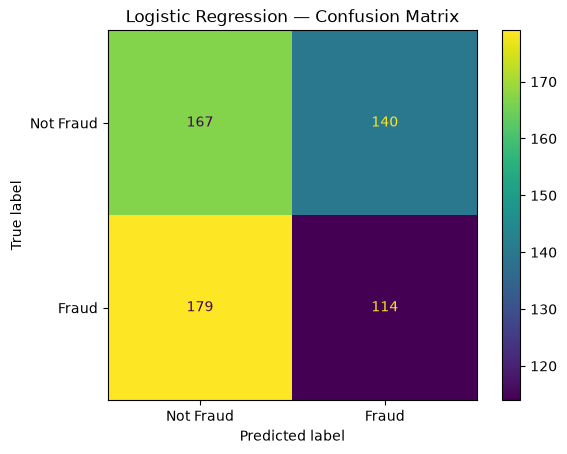

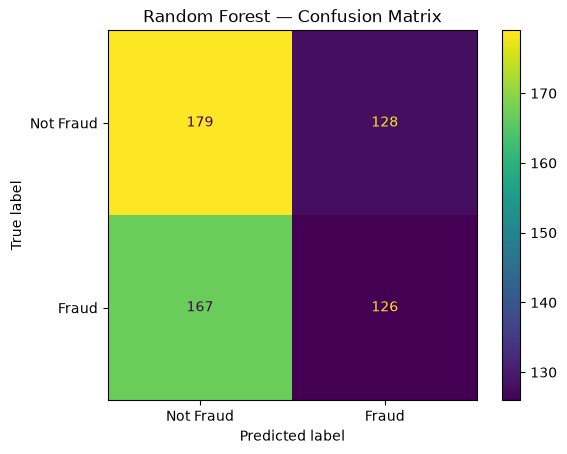

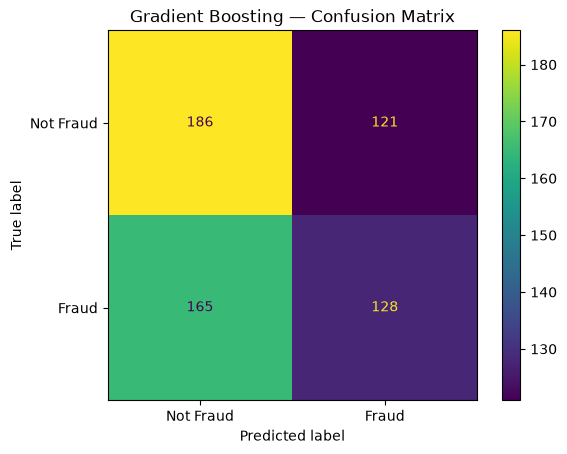

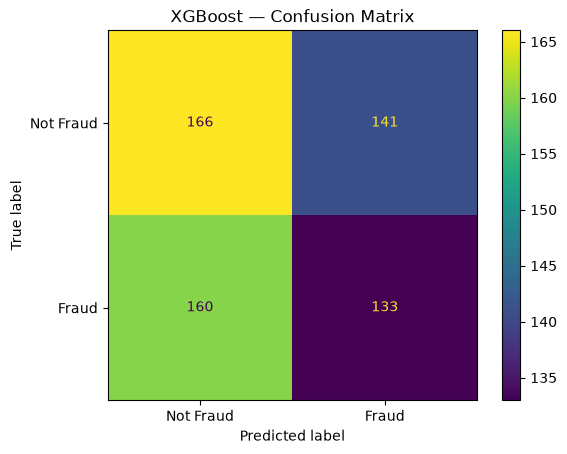

In [151]:
for model_name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Fraud", "Fraud"]
    )

    disp.plot()
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()

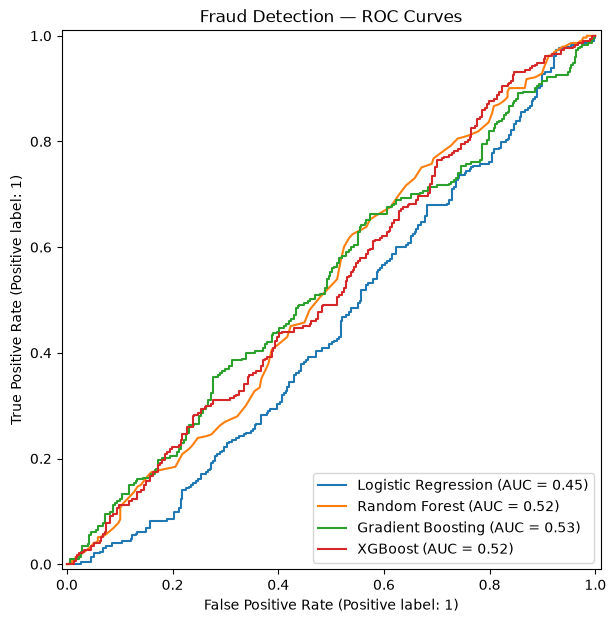

In [152]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10, 7))

for model_name, pipeline in trained_models.items():

    RocCurveDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        name=model_name,
        ax=plt.gca()
    )

plt.title("Fraud Detection — ROC Curves")
plt.show()

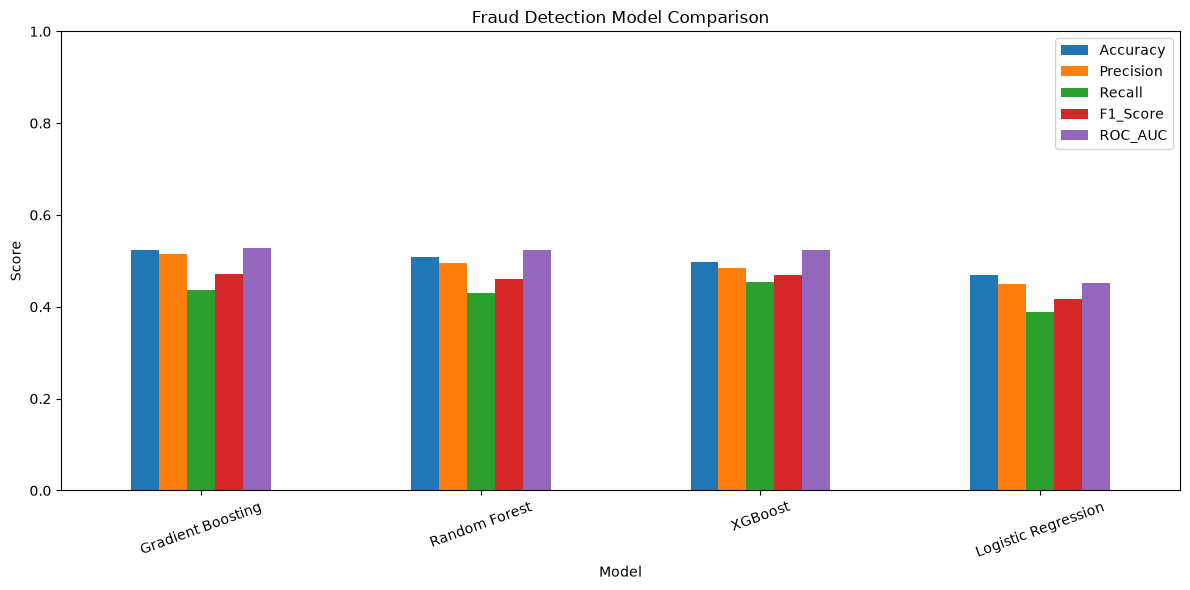

In [153]:
results_plot = results_df.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Fraud Detection Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [154]:
xgb_pipeline = trained_models["XGBoost"]

xgb_model = xgb_pipeline.named_steps["model"]
xgb_preprocessor = xgb_pipeline.named_steps["preprocessor"]

xgb_feature_names = (
    xgb_preprocessor
    .get_feature_names_out()
)

xgb_importance = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance.head(20)

,Feature,Importance
26,cat__Occupation_Govt,0.02
53,cat__Accident_City_Gurugram,0.02
35,cat__Brand_Hyundai,0.02
73,cat__Police_Report_Filed_Yes,0.02
44,cat__Fuel_Type_Hybrid,0.02
49,cat__Accident_City_Ahmedabad,0.02
51,cat__Accident_City_Chennai,0.02
34,cat__Brand_Honda,0.02
54,cat__Accident_City_Hyderabad,0.02
37,cat__Brand_Mahindra,0.02


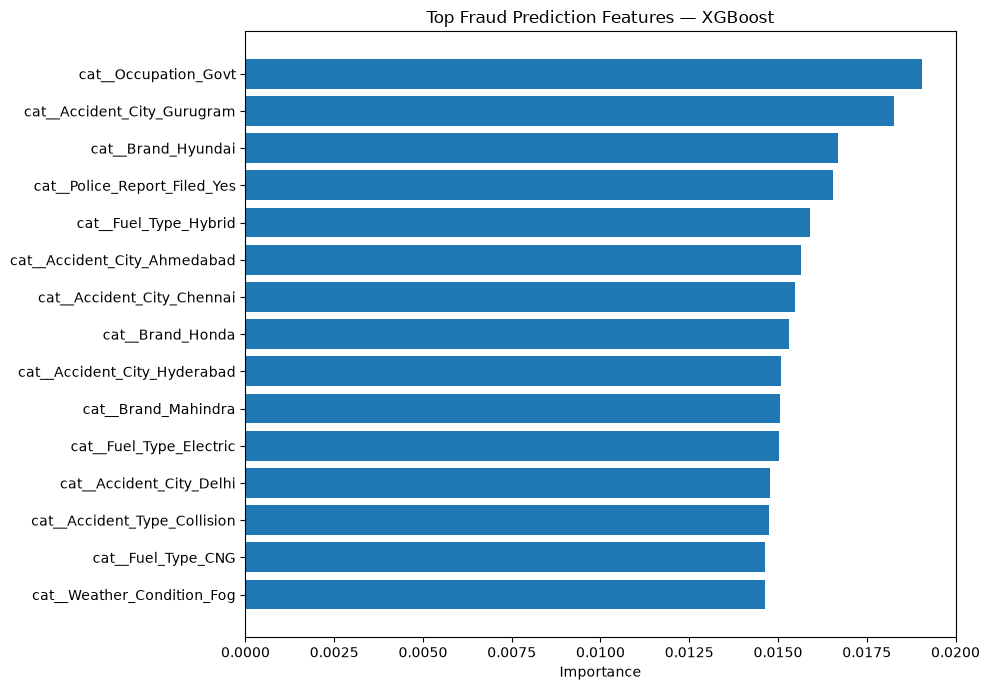

In [155]:
top_features = xgb_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Fraud Prediction Features — XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [156]:
model_comparison = results_df.copy()

model_comparison

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Gradient Boosting,0.52,0.51,0.44,0.47,0.53
1,Random Forest,0.51,0.50,0.43,0.46,0.52
2,XGBoost,0.50,0.49,0.45,0.47,0.52
3,Logistic Regression,0.47,0.45,0.39,0.42,0.45


In [157]:
best_model = results_df.iloc[0]

In [158]:
results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Gradient Boosting,0.52,0.51,0.44,0.47,0.53
1,Random Forest,0.51,0.50,0.43,0.46,0.52
2,XGBoost,0.50,0.49,0.45,0.47,0.52
3,Logistic Regression,0.47,0.45,0.39,0.42,0.45


## 8. Hyperparameter Tuning

The initial baseline models produced relatively weak predictive performance.

To improve model performance, hyperparameters are optimized using
Stratified 5-Fold Cross-Validation on the training data.

The test set remains completely untouched during hyperparameter tuning.

Models evaluated:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost

Primary optimization metric:
ROC-AUC

Additional metrics will be evaluated after tuning, including precision,
recall, F1-score, and accuracy.

In [159]:
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV
)

from scipy.stats import (
    loguniform,
    randint,
    uniform
)

In [160]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [161]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [162]:
logistic_params = {
    "model__C": loguniform(0.001, 100),
    "model__solver": [
        "lbfgs",
        "liblinear"
    ]
}

In [163]:
logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_params,
    n_iter=20,
    scoring="roc_auc",
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

logistic_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': <scipy.stats....0012721F8F0E0>, 'model__solver': ['lbfgs', 'liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected

In [164]:
print("Best Logistic Regression CV ROC-AUC:")
print(logistic_search.best_score_)

print("\nBest Parameters:")
print(logistic_search.best_params_)

Best Logistic Regression CV ROC-AUC:
0.488281915172715

Best Parameters:
{'model__C': np.float64(0.0010090061869151559), 'model__solver': 'liblinear'}


In [165]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [166]:
rf_params = {
    "model__n_estimators": randint(200, 800),
    "model__max_depth": [
        None,
        5,
        10,
        15,
        20,
        30
    ],
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 8),
    "model__max_features": [
        "sqrt",
        "log2",
        None
    ],
    "model__bootstrap": [True, False]
}

In [167]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True, False], 'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....001272691D310>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum

In [168]:
print("Best Random Forest CV ROC-AUC:")
print(rf_search.best_score_)

print("\nBest Parameters:")
print(rf_search.best_params_)

Best Random Forest CV ROC-AUC:
0.5414886796769812

Best Parameters:
{'model__bootstrap': False, 'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 6, 'model__n_estimators': 227}


In [169]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

In [170]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

In [171]:
gb_params = {
    "model__n_estimators": randint(50, 500),
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_depth": randint(2, 6),
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 8),
    "model__subsample": uniform(0.6, 0.4)
}

In [172]:
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_params,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': <scipy.stats....001272691DE50>, 'model__max_depth': <scipy.stats....0012722583820>, 'model__min_samples_leaf': <scipy.stats....00127225EF130>, 'model__min_samples_split': <scipy.stats....00127269AF1D0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the en

In [173]:
print("Best Gradient Boosting CV ROC-AUC:")
print(gb_search.best_score_)

print("\nBest Parameters:")
print(gb_search.best_params_)

Best Gradient Boosting CV ROC-AUC:
0.5150873114387089

Best Parameters:
{'model__learning_rate': np.float64(0.16013335270092907), 'model__max_depth': 4, 'model__min_samples_leaf': 5, 'model__min_samples_split': 11, 'model__n_estimators': 280, 'model__subsample': np.float64(0.8604308102007778)}


In [174]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

In [175]:
xgb_params = {
    "model__n_estimators": randint(100, 700),
    "model__max_depth": randint(2, 9),
    "model__learning_rate": loguniform(0.01, 0.3),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0, 0.5),
    "model__reg_alpha": loguniform(1e-4, 10),
    "model__reg_lambda": loguniform(0.1, 10)
}

In [176]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': <scipy.stats....00127269AE450>, 'model__gamma': <scipy.stats....00127225EFF00>, 'model__learning_rate': <scipy.stats....0012722583BB0>, 'model__max_depth': <scipy.stats....00127220DEA50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where th

In [177]:
print("Best XGBoost CV ROC-AUC:")
print(xgb_search.best_score_)

print("\nBest Parameters:")
print(xgb_search.best_params_)

Best XGBoost CV ROC-AUC:
0.5278168859638205

Best Parameters:
{'model__colsample_bytree': np.float64(0.7531707499015159), 'model__gamma': np.float64(0.4858560476945519), 'model__learning_rate': np.float64(0.1794521447545411), 'model__max_depth': 6, 'model__min_child_weight': 7, 'model__n_estimators': 497, 'model__reg_alpha': np.float64(0.02944272359149678), 'model__reg_lambda': np.float64(1.1103647313054623), 'model__subsample': np.float64(0.7710164073434198)}


In [178]:
tuned_cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "CV_ROC_AUC": [
        logistic_search.best_score_,
        rf_search.best_score_,
        gb_search.best_score_,
        xgb_search.best_score_
    ]
}).sort_values(
    "CV_ROC_AUC",
    ascending=False
).reset_index(drop=True)

tuned_cv_results

,Model,CV_ROC_AUC
0,Random Forest,0.54
1,XGBoost,0.53
2,Gradient Boosting,0.52
3,Logistic Regression,0.49


In [179]:
tuned_models = {
    "Logistic Regression": logistic_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

In [180]:
tuned_test_results = []

for model_name, model in tuned_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1_Score": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

tuned_test_results_df = pd.DataFrame(
    tuned_test_results
).sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

tuned_test_results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,XGBoost,0.53,0.52,0.46,0.49,0.54
1,Gradient Boosting,0.53,0.51,0.48,0.50,0.54
2,Random Forest,0.53,0.52,0.45,0.48,0.54
3,Logistic Regression,0.48,0.45,0.26,0.33,0.47


In [181]:
baseline_results = results_df.copy()

baseline_results["Stage"] = "Baseline"
tuned_test_results_df["Stage"] = "Tuned"

comparison = pd.concat(
    [
        baseline_results,
        tuned_test_results_df
    ],
    ignore_index=True
)

comparison

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Stage
0,Gradient Boosting,0.52,0.51,0.44,0.47,0.53,Baseline
1,Random Forest,0.51,0.50,0.43,0.46,0.52,Baseline
2,XGBoost,0.50,0.49,0.45,0.47,0.52,Baseline
3,Logistic Regression,0.47,0.45,0.39,0.42,0.45,Baseline
4,XGBoost,0.53,0.52,0.46,0.49,0.54,Tuned
5,Gradient Boosting,0.53,0.51,0.48,0.50,0.54,Tuned
6,Random Forest,0.53,0.52,0.45,0.48,0.54,Tuned
7,Logistic Regression,0.48,0.45,0.26,0.33,0.47,Tuned


In [182]:
roc_comparison = pd.concat([
    baseline_results[
        ["Model", "ROC_AUC"]
    ].rename(
        columns={"ROC_AUC": "Baseline_ROC_AUC"}
    ),
    
    tuned_test_results_df[
        ["Model", "ROC_AUC"]
    ].rename(
        columns={"ROC_AUC": "Tuned_ROC_AUC"}
    )
],
axis=1)

roc_comparison

,Model,Baseline_ROC_AUC,Model,Tuned_ROC_AUC
0,Gradient Boosting,0.53,XGBoost,0.54
1,Random Forest,0.52,Gradient Boosting,0.54
2,XGBoost,0.52,Random Forest,0.54
3,Logistic Regression,0.45,Logistic Regression,0.47


In [183]:
tuned_cv_results

,Model,CV_ROC_AUC
0,Random Forest,0.54
1,XGBoost,0.53
2,Gradient Boosting,0.52
3,Logistic Regression,0.49


In [184]:
tuned_test_results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Stage
0,XGBoost,0.53,0.52,0.46,0.49,0.54,Tuned
1,Gradient Boosting,0.53,0.51,0.48,0.50,0.54,Tuned
2,Random Forest,0.53,0.52,0.45,0.48,0.54,Tuned
3,Logistic Regression,0.48,0.45,0.26,0.33,0.47,Tuned


## 9. Fraud Signal Analysis

The initial classification models produced weak predictive performance.

Before further model optimization, the relationship between the fraud
target and available business features is examined.

The purpose of this analysis is to determine whether the dataset contains
meaningful patterns that can be exploited for fraud prediction.

The analysis focuses on:

- Fraud rates across categorical variables
- Differences in numerical variables between fraud classes
- Correlation and mutual information
- Additional domain-specific features

This step helps distinguish model limitations from limitations in the
underlying synthetic data.

In [185]:
fraud_summary = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": y.value_counts(normalize=True) * 100
})

fraud_summary.index = ["Not Fraud", "Fraud"]

fraud_summary

,Count,Percentage
Not Fraud,1536,51.20
Fraud,1464,48.80


In [186]:
def fraud_rate_by_category(df, column):
    result = (
        df.groupby(column)["Fraud_Target"]
        .agg(
            Claims="count",
            Fraud_Count="sum",
            Fraud_Rate="mean"
        )
        .sort_values("Fraud_Rate", ascending=False)
    )

    result["Fraud_Rate"] = (
        result["Fraud_Rate"] * 100
    ).round(2)

    return result

In [187]:
fraud_rate_by_category(
    fraud_model_df,
    "Accident_Type"
)

,Claims,Fraud_Count,Fraud_Rate
Accident_Type,,,
Collision,503,267,53.08
Fire,503,249,49.50
Major Accident,507,248,48.92
Flood,509,243,47.74
Theft,509,243,47.74
Minor Accident,469,214,45.63


In [188]:
fraud_rate_by_category(
    fraud_model_df,
    "Weather_Condition"
)

,Claims,Fraud_Count,Fraud_Rate
Weather_Condition,,,
Sunny,609,313,51.40
Rainy,606,300,49.50
Cloudy,601,293,48.75
Storm,592,280,47.30
Fog,592,278,46.96


In [189]:
fraud_rate_by_category(
    fraud_model_df,
    "Police_Report_Filed"
)

,Claims,Fraud_Count,Fraud_Rate
Police_Report_Filed,,,
Yes,1471,731,49.69
No,1529,733,47.94


In [191]:
fraud_rate_by_category(
    fraud_model_df,
    "Injuries"
)

,Claims,Fraud_Count,Fraud_Rate
Injuries,,,
Unknown,979,488,49.85
Serious,980,481,49.08
Minor,1041,495,47.55


In [192]:
fraud_rate_by_category(
    fraud_model_df,
    "Policy_Type"
)

,Claims,Fraud_Count,Fraud_Rate
Policy_Type,,,
Zero Depreciation,1008,495,49.11
Comprehensive,1098,539,49.09
Third Party,894,430,48.10


In [193]:
fraud_rate_by_category(
    fraud_model_df,
    "Vehicle_Type"
)

,Claims,Fraud_Count,Fraud_Rate
Vehicle_Type,,,
SUV,794,396,49.87
Sedan,771,383,49.68
Hatchback,738,354,47.97
Motorcycle,697,331,47.49


In [194]:
fraud_rate_by_category(
    fraud_model_df,
    "Fuel_Type"
)

,Claims,Fraud_Count,Fraud_Rate
Fuel_Type,,,
Petrol,607,324,53.38
Electric,570,282,49.47
Diesel,646,308,47.68
Hybrid,595,279,46.89
CNG,582,271,46.56


In [195]:
numerical_model_features = [
    "Age",
    "Annual_Income",
    "Driving_Experience_Years",
    "Manufacture_Year",
    "Engine_CC",
    "Vehicle_Value",
    "Coverage_Amount",
    "Premium_Amount",
    "No_Claim_Bonus",
    "Estimated_Damage_Cost",
    "Claim_Amount",
    "Vehicle_Age",
    "Premium_Coverage_Ratio",
    "Claim_Damage_Ratio",
    "Claim_Vehicle_Value_Ratio"
]

In [196]:
fraud_numeric_summary = (
    fraud_model_df
    .groupby("Fraud_Target")[numerical_model_features]
    .mean()
    .T
)

fraud_numeric_summary.columns = [
    "Not_Fraud",
    "Fraud"
]

fraud_numeric_summary

,Not_Fraud,Fraud
Age,45.96,46.13
Annual_Income,"2,576,794.26","2,588,132.85"
Driving_Experience_Years,15.57,15.59
Manufacture_Year,"2,017.94","2,018.04"
Engine_CC,"1,290.23","1,277.32"
Vehicle_Value,"4,142,149.22","4,239,831.27"
Coverage_Amount,"4,995,788.89","5,059,380.94"
Premium_Amount,"41,784.40","41,377.35"
No_Claim_Bonus,28.41,28.56
Estimated_Damage_Cost,"1,120,427.32","1,172,759.06"


In [197]:
fraud_numeric_summary["Difference_%"] = (
    (
        fraud_numeric_summary["Fraud"]
        - fraud_numeric_summary["Not_Fraud"]
    )
    / fraud_numeric_summary["Not_Fraud"]
    * 100
)

fraud_numeric_summary.sort_values(
    "Difference_%",
    ascending=False
)

,Not_Fraud,Fraud,Difference_%
Claim_Amount,"1,094,900.52","1,148,011.22",4.85
Estimated_Damage_Cost,"1,120,427.32","1,172,759.06",4.67
Vehicle_Value,"4,142,149.22","4,239,831.27",2.36
Coverage_Amount,"4,995,788.89","5,059,380.94",1.27
No_Claim_Bonus,28.41,28.56,0.51
Claim_Damage_Ratio,0.94,0.95,0.46
Annual_Income,"2,576,794.26","2,588,132.85",0.44
Age,45.96,46.13,0.37
Driving_Experience_Years,15.57,15.59,0.10
Manufacture_Year,"2,017.94","2,018.04",0.01


In [198]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

In [199]:
mi_df = fraud_model_df[
    feature_columns + ["Fraud_Target"]
].copy()

In [200]:
for column in categorical_features:
    mi_df[column] = (
        mi_df[column]
        .astype("category")
        .cat.codes
    )

In [201]:
mi_df.isna().sum().sum()

np.int64(0)

In [202]:
X_mi = mi_df.drop(
    columns=["Fraud_Target"]
)

y_mi = mi_df["Fraud_Target"]

In [203]:
mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

In [204]:
mi_results = pd.DataFrame({
    "Feature": X_mi.columns,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
)

mi_results.head(20)

,Feature,Mutual_Information
11,Vehicle_Value,0.02
4,Annual_Income,0.02
6,Vehicle_Type,0.02
12,Policy_Type,0.02
20,Injuries,0.02
24,Premium_Coverage_Ratio,0.01
7,Brand,0.01
29,Claim_DayOfWeek,0.01
16,Accident_City,0.01
14,Premium_Amount,0.01


In [205]:
fraud_model_df["Claim_Coverage_Ratio"] = (
    fraud_model_df["Claim_Amount"]
    / fraud_model_df["Coverage_Amount"]
)

In [206]:
fraud_model_df["Damage_Vehicle_Value_Ratio"] = (
    fraud_model_df["Estimated_Damage_Cost"]
    / fraud_model_df["Vehicle_Value"]
)

In [207]:
fraud_model_df["Claim_Income_Ratio"] = (
    fraud_model_df["Claim_Amount"]
    / fraud_model_df["Annual_Income"]
)

In [208]:
policy_dates = policies[
    [
        "Policy_ID",
        "Start_Date",
        "End_Date"
    ]
].copy()

In [209]:
fraud_model_df = fraud_model_df.merge(
    policy_dates,
    on="Policy_ID",
    how="left"
)

In [212]:
# ============================================================
# RESTORE DATES FOR POLICY-TIMING FEATURES
# ============================================================

# Bring Claim_Date back from the original claims dataframe
if "Claim_Date" not in fraud_model_df.columns:

    claim_dates = claims[
        ["Claim_ID", "Claim_Date"]
    ].copy()

    fraud_model_df = fraud_model_df.merge(
        claim_dates,
        on="Claim_ID",
        how="left",
        validate="one_to_one"
    )


# Bring policy dates back if they are not already present
if "Start_Date" not in fraud_model_df.columns:

    policy_dates = policies[
        ["Policy_ID", "Start_Date", "End_Date"]
    ].copy()

    fraud_model_df = fraud_model_df.merge(
        policy_dates,
        on="Policy_ID",
        how="left",
        validate="many_to_one"
    )

In [214]:
print(
    fraud_model_df[
        ["Claim_ID", "Claim_Date", "Policy_ID", "Start_Date", "End_Date"]
    ].head()
)

     Claim_ID Claim_Date   Policy_ID Start_Date   End_Date
0  CLM_000001 2020-10-18  POL_001139 2020-05-02 2021-05-02
1  CLM_000002 2023-02-28  POL_000541 2022-05-26 2023-05-26
2  CLM_000003 2023-07-28  POL_001434 2023-01-23 2024-01-23
3  CLM_000004 2021-01-22  POL_000572 2020-10-15 2021-10-15
4  CLM_000005 2020-10-29  POL_000434 2020-03-14 2021-03-14


In [215]:
fraud_model_df["Policy_Age_At_Claim"] = (
    fraud_model_df["Claim_Date"]
    - fraud_model_df["Start_Date"]
).dt.days

In [216]:
fraud_model_df["Days_To_Policy_End"] = (
    fraud_model_df["End_Date"]
    - fraud_model_df["Claim_Date"]
).dt.days

In [217]:
fraud_model_df["Early_Claim"] = (
    fraud_model_df["Policy_Age_At_Claim"] <= 30
).astype(int)

In [218]:
fraud_model_df[
    [
        "Claim_ID",
        "Claim_Date",
        "Start_Date",
        "End_Date",
        "Policy_Age_At_Claim",
        "Days_To_Policy_End",
        "Early_Claim"
    ]
].head(10)

,Claim_ID,Claim_Date,Start_Date,End_Date,Policy_Age_At_Claim,Days_To_Policy_End,Early_Claim
0,CLM_000001,2020-10-18,2020-05-02,2021-05-02,169,196,0
1,CLM_000002,2023-02-28,2022-05-26,2023-05-26,278,87,0
2,CLM_000003,2023-07-28,2023-01-23,2024-01-23,186,179,0
3,CLM_000004,2021-01-22,2020-10-15,2021-10-15,99,266,0
4,CLM_000005,2020-10-29,2020-03-14,2021-03-14,229,136,0
5,CLM_000006,2022-08-02,2022-06-07,2023-06-07,56,309,0
6,CLM_000007,2021-08-14,2020-10-29,2021-10-29,289,76,0
7,CLM_000008,2021-04-23,2020-06-18,2021-06-18,309,56,0
8,CLM_000009,2025-08-24,2024-08-30,2025-08-30,359,6,0
9,CLM_000010,2025-02-17,2024-03-21,2025-03-21,333,32,0


In [219]:
fraud_model_df[
    [
        "Policy_Age_At_Claim",
        "Days_To_Policy_End"
    ]
].describe()

,Policy_Age_At_Claim,Days_To_Policy_End
count,"3,000.00","3,000.00"
mean,183.44,181.56
std,105.42,105.42
min,0.00,0.00
25%,91.75,91.00
50%,184.00,181.00
75%,274.00,273.25
max,365.00,365.00


In [221]:
print(
    "Claims before policy start:",
    (
        fraud_model_df["Policy_Age_At_Claim"] < 0
    ).sum()
)

print(
    "Claims after policy end:",
    (
        fraud_model_df["Days_To_Policy_End"] < 0
    ).sum()
)

Claims before policy start: 0
Claims after policy end: 0


In [222]:
fraud_model_df.groupby(
    "Early_Claim"
)["Fraud_Target"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
Early_Claim,,,
0,2764,1354,0.49
1,236,110,0.47


In [223]:
fraud_model_df.groupby(
    "Early_Claim"
)["Fraud_Target"].mean() * 100

Early_Claim
0   48.99
1   46.61
Name: Fraud_Target, dtype: float64

In [224]:
fraud_model_df.drop(
    columns=["Claim_Date", "Start_Date", "End_Date"],
    inplace=True
)

In [225]:
fraud_rate_by_category(fraud_model_df, "Accident_Type")

,Claims,Fraud_Count,Fraud_Rate
Accident_Type,,,
Collision,503,267,53.08
Fire,503,249,49.50
Major Accident,507,248,48.92
Flood,509,243,47.74
Theft,509,243,47.74
Minor Accident,469,214,45.63


In [226]:
fraud_numeric_summary

,Not_Fraud,Fraud,Difference_%
Age,45.96,46.13,0.37
Annual_Income,"2,576,794.26","2,588,132.85",0.44
Driving_Experience_Years,15.57,15.59,0.10
Manufacture_Year,"2,017.94","2,018.04",0.01
Engine_CC,"1,290.23","1,277.32",-1.00
Vehicle_Value,"4,142,149.22","4,239,831.27",2.36
Coverage_Amount,"4,995,788.89","5,059,380.94",1.27
Premium_Amount,"41,784.40","41,377.35",-0.97
No_Claim_Bonus,28.41,28.56,0.51
Estimated_Damage_Cost,"1,120,427.32","1,172,759.06",4.67


In [227]:
fraud_numeric_summary

,Not_Fraud,Fraud,Difference_%
Age,45.96,46.13,0.37
Annual_Income,"2,576,794.26","2,588,132.85",0.44
Driving_Experience_Years,15.57,15.59,0.10
Manufacture_Year,"2,017.94","2,018.04",0.01
Engine_CC,"1,290.23","1,277.32",-1.00
Vehicle_Value,"4,142,149.22","4,239,831.27",2.36
Coverage_Amount,"4,995,788.89","5,059,380.94",1.27
Premium_Amount,"41,784.40","41,377.35",-0.97
No_Claim_Bonus,28.41,28.56,0.51
Estimated_Damage_Cost,"1,120,427.32","1,172,759.06",4.67


In [228]:
fraud_model_df.groupby(
    "Early_Claim"
)["Fraud_Target"].mean() * 100

Early_Claim
0   48.99
1   46.61
Name: Fraud_Target, dtype: float64

## 10. Synthetic Fraud-Risk Target Generation

The original `Fraud_Suspected` target was found to have very weak
relationships with the available predictors.

Because the dataset is synthetic, a secondary target is created for
demonstration of supervised fraud-risk modeling.

The new target is based only on observable claim, policy, customer,
and vehicle characteristics that can reasonably be available during
claim assessment.

The original `Fraud_Suspected` variable is preserved and is not used
to construct the new target.

In [229]:
fraud_model_df["Claim_Coverage_Ratio"] = (
    fraud_model_df["Claim_Amount"]
    / fraud_model_df["Coverage_Amount"]
)

fraud_model_df["Damage_Vehicle_Value_Ratio"] = (
    fraud_model_df["Estimated_Damage_Cost"]
    / fraud_model_df["Vehicle_Value"]
)

fraud_model_df["Claim_Income_Ratio"] = (
    fraud_model_df["Claim_Amount"]
    / fraud_model_df["Annual_Income"]
)

In [230]:
fraud_model_df[
    [
        "Claim_Coverage_Ratio",
        "Claim_Damage_Ratio",
        "Claim_Vehicle_Value_Ratio",
        "Damage_Vehicle_Value_Ratio",
        "Claim_Income_Ratio",
        "Policy_Age_At_Claim"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Claim_Coverage_Ratio,"3,000.00",0.30,0.24,0.00,0.12,0.24,0.42,1.00
Claim_Damage_Ratio,"3,000.00",0.95,0.10,0.12,0.95,0.98,0.99,1.00
Claim_Vehicle_Value_Ratio,"3,000.00",0.59,1.13,0.00,0.11,0.26,0.54,14.97
Damage_Vehicle_Value_Ratio,"3,000.00",0.60,1.15,0.00,0.12,0.27,0.56,15.11
Claim_Income_Ratio,"3,000.00",0.75,1.08,0.00,0.19,0.43,0.81,10.72
Policy_Age_At_Claim,"3,000.00",183.44,105.42,0.00,91.75,184.00,274.00,365.00


In [231]:
fraud_model_df[
    [
        "Claim_Coverage_Ratio",
        "Claim_Damage_Ratio",
        "Claim_Vehicle_Value_Ratio",
        "Damage_Vehicle_Value_Ratio",
        "Claim_Income_Ratio",
        "Policy_Age_At_Claim"
    ]
].quantile(
    [0.75, 0.90, 0.95, 0.99]
).T

,0.75,0.90,0.95,0.99
Claim_Coverage_Ratio,0.42,0.68,0.83,0.96
Claim_Damage_Ratio,0.99,1.00,1.00,1.00
Claim_Vehicle_Value_Ratio,0.54,1.30,2.35,5.87
Damage_Vehicle_Value_Ratio,0.56,1.33,2.42,5.88
Claim_Income_Ratio,0.81,1.78,2.74,5.56
Policy_Age_At_Claim,274.00,328.00,348.00,361.00


In [232]:
fraud_model_df["High_Claim_Coverage"] = (
    fraud_model_df["Claim_Coverage_Ratio"]
    >= fraud_model_df["Claim_Coverage_Ratio"].quantile(0.90)
).astype(int)

fraud_model_df["High_Claim_Damage_Ratio"] = (
    fraud_model_df["Claim_Damage_Ratio"]
    >= fraud_model_df["Claim_Damage_Ratio"].quantile(0.90)
).astype(int)

fraud_model_df["High_Claim_Vehicle_Ratio"] = (
    fraud_model_df["Claim_Vehicle_Value_Ratio"]
    >= fraud_model_df["Claim_Vehicle_Value_Ratio"].quantile(0.90)
).astype(int)

fraud_model_df["High_Damage_Vehicle_Ratio"] = (
    fraud_model_df["Damage_Vehicle_Value_Ratio"]
    >= fraud_model_df["Damage_Vehicle_Value_Ratio"].quantile(0.90)
).astype(int)

fraud_model_df["High_Claim_Income_Ratio"] = (
    fraud_model_df["Claim_Income_Ratio"]
    >= fraud_model_df["Claim_Income_Ratio"].quantile(0.90)
).astype(int)

In [233]:
fraud_model_df["No_Police_Report"] = (
    fraud_model_df["Police_Report_Filed"] == "No"
).astype(int)

fraud_model_df["Serious_Injury"] = (
    fraud_model_df["Injuries"] == "Serious"
).astype(int)

fraud_model_df["Theft_or_Fire"] = (
    fraud_model_df["Accident_Type"].isin(
        ["Theft", "Fire"]
    )
).astype(int)

fraud_model_df["Early_Claim"] = (
    fraud_model_df["Policy_Age_At_Claim"] <= 30
).astype(int)

In [234]:
fraud_model_df["Synthetic_Fraud_Score"] = (
    2 * fraud_model_df["High_Claim_Coverage"]
    + 2 * fraud_model_df["High_Claim_Damage_Ratio"]
    + 2 * fraud_model_df["High_Claim_Vehicle_Ratio"]
    + 1 * fraud_model_df["High_Damage_Vehicle_Ratio"]
    + 1 * fraud_model_df["High_Claim_Income_Ratio"]
    + 1 * fraud_model_df["No_Police_Report"]
    + 1 * fraud_model_df["Serious_Injury"]
    + 1 * fraud_model_df["Theft_or_Fire"]
    + 2 * fraud_model_df["Early_Claim"]
)

In [235]:
fraud_model_df[
    "Synthetic_Fraud_Score"
].value_counts().sort_index()

Synthetic_Fraud_Score
0    410
1    878
2    709
3    432
4    276
5    152
6     85
7     43
8      9
9      6
Name: count, dtype: int64

In [236]:
fraud_model_df[
    "Synthetic_Fraud_Score"
].describe()

count   3,000.00
mean        2.13
std         1.68
min         0.00
25%         1.00
50%         2.00
75%         3.00
max         9.00
Name: Synthetic_Fraud_Score, dtype: float64

### Synthetic Fraud Target

A secondary fraud target is generated from the synthetic fraud-risk score.

A claim with a fraud-risk score of 3 or higher is classified as
`Synthetic_Fraud_Target = 1`, while claims below 3 are classified as 0.

The original `Fraud_Suspected` field is retained separately for comparison.

This target is intended for demonstrating the end-to-end fraud prediction
workflow on synthetic data and should not be interpreted as a real-world
fraud label.

In [237]:
fraud_model_df["Synthetic_Fraud_Target"] = (
    fraud_model_df["Synthetic_Fraud_Score"] >= 3
).astype(int)

In [238]:
synthetic_target_summary = pd.DataFrame({
    "Count": fraud_model_df["Synthetic_Fraud_Target"].value_counts(),
    "Percentage": (
        fraud_model_df["Synthetic_Fraud_Target"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
})

synthetic_target_summary.index = [
    "Not Fraud",
    "Fraud"
]

synthetic_target_summary

,Count,Percentage
Not Fraud,1997,66.57
Fraud,1003,33.43


In [239]:
fraud_model_df.groupby(
    "Synthetic_Fraud_Score"
)["Synthetic_Fraud_Target"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
Synthetic_Fraud_Score,,,
0,410,0,0.00
1,878,0,0.00
2,709,0,0.00
3,432,432,1.00
4,276,276,1.00
5,152,152,1.00
6,85,85,1.00
7,43,43,1.00
8,9,9,1.00


In [241]:
pd.crosstab(
    fraud_model_df["Fraud_Suspected"],
    fraud_model_df["Synthetic_Fraud_Target"],
    normalize="index"
).round(3)

Synthetic_Fraud_Target,0,1
Fraud_Suspected,,
No,0.66,0.34
Yes,0.67,0.33


In [242]:
feature_columns_v2 = [
    # Customer
    "Gender",
    "Age",
    "Marital_Status",
    "Occupation",
    "Annual_Income",
    "Driving_Experience_Years",

    # Vehicle
    "Vehicle_Type",
    "Brand",
    "Manufacture_Year",
    "Fuel_Type",
    "Engine_CC",
    "Vehicle_Value",

    # Policy
    "Policy_Type",
    "Coverage_Amount",
    "Premium_Amount",
    "No_Claim_Bonus",

    # Claim
    "Accident_City",
    "Accident_Type",
    "Weather_Condition",
    "Police_Report_Filed",
    "Injuries",
    "Estimated_Damage_Cost",
    "Claim_Amount",

    # Existing engineered features
    "Vehicle_Age",
    "Premium_Coverage_Ratio",
    "Claim_Damage_Ratio",
    "Claim_Vehicle_Value_Ratio",

    # Temporal
    "Claim_Year",
    "Claim_Month",
    "Claim_DayOfWeek",
    "Claim_Weekend",

    # New fraud-risk features
    "Claim_Coverage_Ratio",
    "Damage_Vehicle_Value_Ratio",
    "Claim_Income_Ratio",
    "Policy_Age_At_Claim",
    "Days_To_Policy_End",
    "Early_Claim",
    "High_Claim_Coverage",
    "High_Claim_Damage_Ratio",
    "High_Claim_Vehicle_Ratio",
    "High_Damage_Vehicle_Ratio",
    "High_Claim_Income_Ratio",
    "No_Police_Report",
    "Serious_Injury",
    "Theft_or_Fire"
]

In [243]:
fraud_model_df.drop(
    columns=[
        "Claim_Date",
        "Start_Date",
        "End_Date"
    ],
    inplace=True,
    errors="ignore"
)

In [244]:
model_df_v2 = fraud_model_df[
    feature_columns_v2 + ["Synthetic_Fraud_Target"]
].copy()

In [245]:
print("New model dataset shape:", model_df_v2.shape)

New model dataset shape: (3000, 46)


In [246]:
X_v2 = model_df_v2.drop(
    columns=["Synthetic_Fraud_Target"]
)

y_v2 = model_df_v2["Synthetic_Fraud_Target"]

In [247]:
missing_v2 = (
    model_df_v2
    .isna()
    .sum()
)

missing_v2[missing_v2 > 0]

Series([], dtype: int64)

In [248]:
numeric_features_v2 = [
    "Age",
    "Annual_Income",
    "Driving_Experience_Years",
    "Manufacture_Year",
    "Engine_CC",
    "Vehicle_Value",
    "Coverage_Amount",
    "Premium_Amount",
    "No_Claim_Bonus",
    "Estimated_Damage_Cost",
    "Claim_Amount",
    "Vehicle_Age",
    "Premium_Coverage_Ratio",
    "Claim_Damage_Ratio",
    "Claim_Vehicle_Value_Ratio",
    "Claim_Year",
    "Claim_Month",
    "Claim_DayOfWeek",
    "Claim_Weekend",
    "Claim_Coverage_Ratio",
    "Damage_Vehicle_Value_Ratio",
    "Claim_Income_Ratio",
    "Policy_Age_At_Claim",
    "Days_To_Policy_End",
    "Early_Claim",
    "High_Claim_Coverage",
    "High_Claim_Damage_Ratio",
    "High_Claim_Vehicle_Ratio",
    "High_Damage_Vehicle_Ratio",
    "High_Claim_Income_Ratio",
    "No_Police_Report",
    "Serious_Injury",
    "Theft_or_Fire"
]

In [249]:
categorical_features_v2 = [
    "Gender",
    "Marital_Status",
    "Occupation",
    "Vehicle_Type",
    "Brand",
    "Fuel_Type",
    "Policy_Type",
    "Accident_City",
    "Accident_Type",
    "Weather_Condition",
    "Police_Report_Filed",
    "Injuries"
]

In [250]:
print(
    "Listed features:",
    len(numeric_features_v2) + len(categorical_features_v2)
)

print(
    "Actual features:",
    len(X_v2.columns)
)

Listed features: 45
Actual features: 45


In [251]:
preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_v2
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_v2
        )
    ],
    remainder="drop"
)

In [252]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.20,
    random_state=42,
    stratify=y_v2
)

In [253]:
print("Training:", X_train_v2.shape)
print("Testing :", X_test_v2.shape)

print("\nTraining fraud rate:")
print(y_train_v2.mean())

print("\nTesting fraud rate:")
print(y_test_v2.mean())

Training: (2400, 45)
Testing : (600, 45)

Training fraud rate:
0.33416666666666667

Testing fraud rate:
0.335


## 11. Fraud Prediction Model Training

The fraud models are trained using the synthetically generated
`Synthetic_Fraud_Target`.

The target was generated from observable insurance risk characteristics.
Therefore, the resulting model demonstrates an end-to-end fraud-risk
prediction workflow on synthetic data.

Four classification algorithms are evaluated:

- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost

All models use the same preprocessing pipeline and the same training/test
split.

In [254]:
models_v2 = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

In [255]:
trained_models_v2 = {}
results_v2 = []

for model_name, model in models_v2.items():

    print("=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_v2),
            ("model", model)
        ]
    )

    pipeline.fit(
        X_train_v2,
        y_train_v2
    )

    y_pred = pipeline.predict(X_test_v2)
    y_prob = pipeline.predict_proba(X_test_v2)[:, 1]

    results_v2.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_v2,
            y_pred
        ),
        "Precision": precision_score(
            y_test_v2,
            y_pred
        ),
        "Recall": recall_score(
            y_test_v2,
            y_pred
        ),
        "F1_Score": f1_score(
            y_test_v2,
            y_pred
        ),
        "ROC_AUC": roc_auc_score(
            y_test_v2,
            y_prob
        )
    })

    trained_models_v2[model_name] = pipeline

    print("Training completed.\n")

Training: Logistic Regression
Training completed.

Training: Random Forest
Training completed.

Training: Gradient Boosting
Training completed.

Training: XGBoost
Training completed.



In [256]:
results_v2_df = pd.DataFrame(
    results_v2
).sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

results_v2_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,1.00,1.00,1.00,1.00,1.00
1,Random Forest,0.99,0.98,0.99,0.99,1.00
2,XGBoost,0.99,0.99,0.99,0.99,1.00
3,Gradient Boosting,0.99,0.99,0.98,0.98,1.00


In [257]:
for model_name, pipeline in trained_models_v2.items():

    y_pred = pipeline.predict(X_test_v2)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test_v2,
            y_pred,
            target_names=[
                "Not Fraud",
                "Fraud"
            ]
        )
    )


Logistic Regression
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00       399
       Fraud       1.00      1.00      1.00       201

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Random Forest
              precision    recall  f1-score   support

   Not Fraud       0.99      0.99      0.99       399
       Fraud       0.98      0.99      0.99       201

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600


Gradient Boosting
              precision    recall  f1-score   support

   Not Fraud       0.99      1.00      0.99       399
       Fraud       0.99      0.98      0.98       201

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       

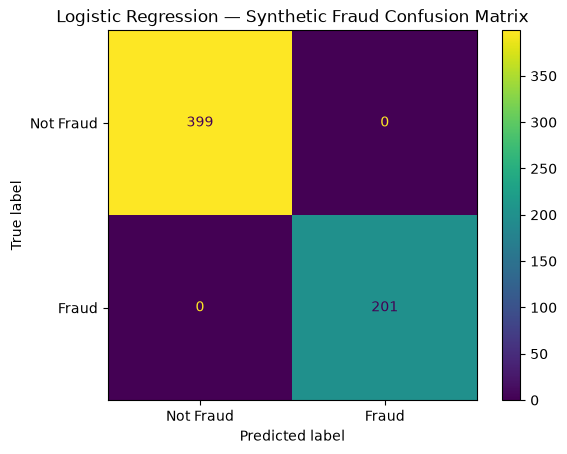

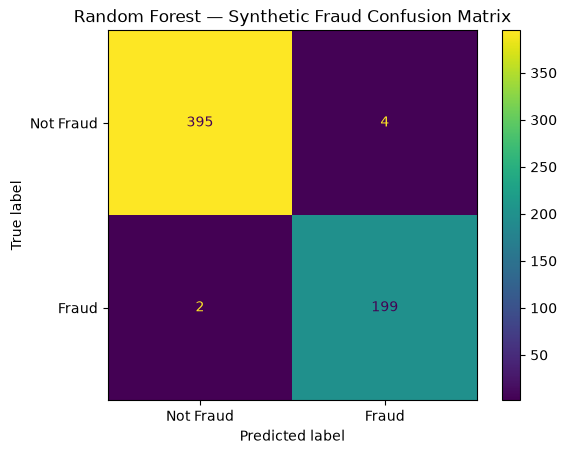

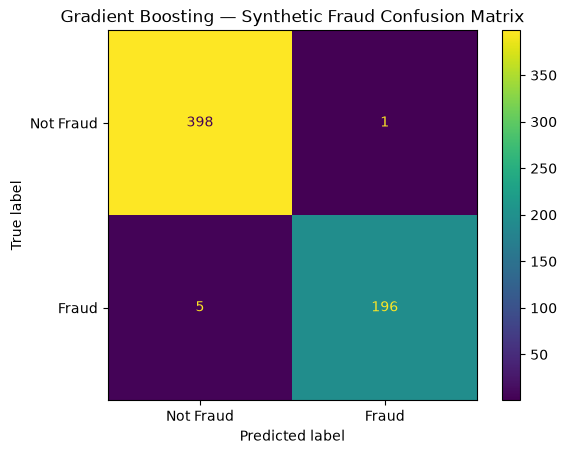

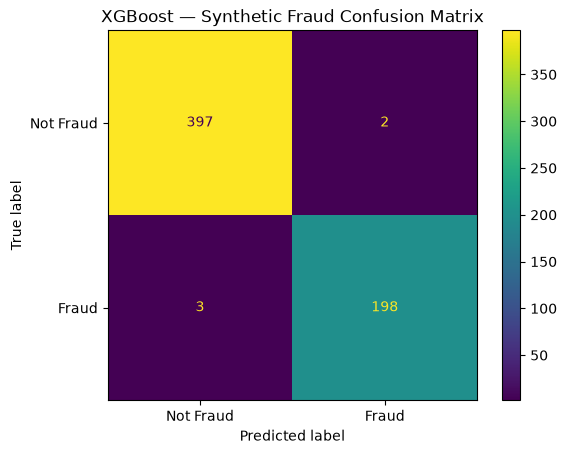

In [258]:
for model_name, pipeline in trained_models_v2.items():

    y_pred = pipeline.predict(X_test_v2)

    cm = confusion_matrix(
        y_test_v2,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Not Fraud",
            "Fraud"
        ]
    )

    disp.plot()

    plt.title(
        f"{model_name} — Synthetic Fraud Confusion Matrix"
    )

    plt.show()

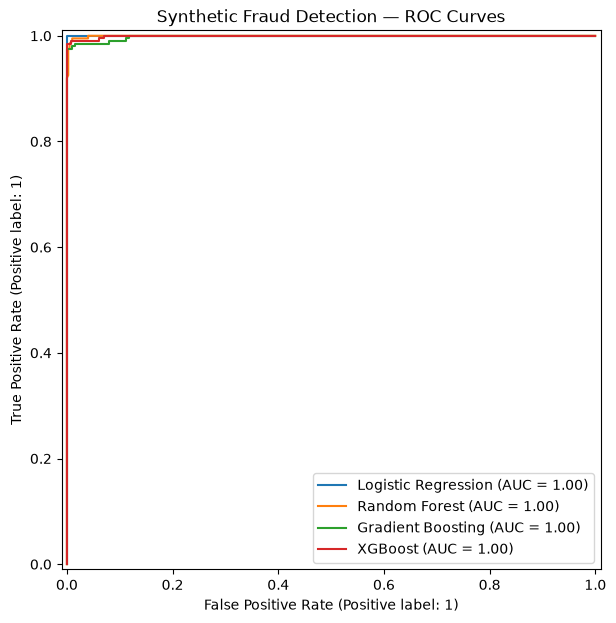

In [259]:
plt.figure(figsize=(10, 7))

for model_name, pipeline in trained_models_v2.items():

    RocCurveDisplay.from_estimator(
        pipeline,
        X_test_v2,
        y_test_v2,
        name=model_name,
        ax=plt.gca()
    )

plt.title(
    "Synthetic Fraud Detection — ROC Curves"
)

plt.show()

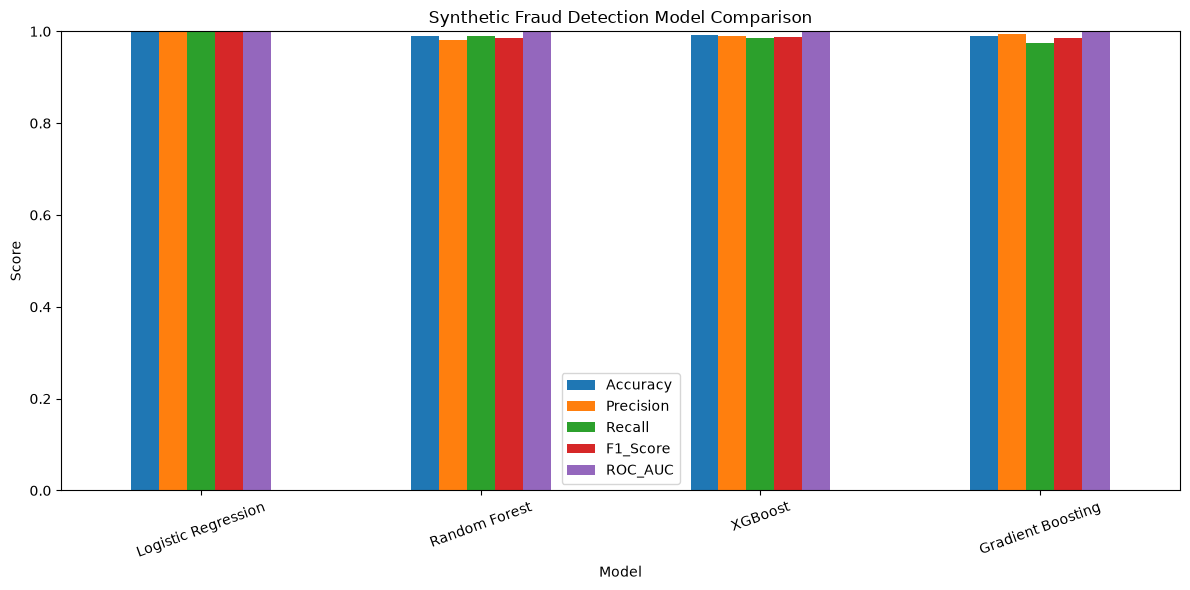

In [260]:
results_plot_v2 = results_v2_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ]
]

results_plot_v2.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Synthetic Fraud Detection Model Comparison"
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [261]:
xgb_pipeline_v2 = trained_models_v2["XGBoost"]

xgb_model_v2 = (
    xgb_pipeline_v2
    .named_steps["model"]
)

xgb_preprocessor_v2 = (
    xgb_pipeline_v2
    .named_steps["preprocessor"]
)

xgb_feature_names_v2 = (
    xgb_preprocessor_v2
    .get_feature_names_out()
)

xgb_importance_v2 = pd.DataFrame({
    "Feature": xgb_feature_names_v2,
    "Importance": xgb_model_v2.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance_v2.head(20)

,Feature,Importance
28,num__High_Damage_Vehicle_Ratio,0.17
27,num__High_Claim_Vehicle_Ratio,0.09
14,num__Claim_Vehicle_Value_Ratio,0.08
25,num__High_Claim_Coverage,0.07
22,num__Policy_Age_At_Claim,0.05
13,num__Claim_Damage_Ratio,0.04
29,num__High_Claim_Income_Ratio,0.04
80,cat__Accident_Type_Theft,0.03
32,num__Theft_or_Fire,0.03
31,num__Serious_Injury,0.03


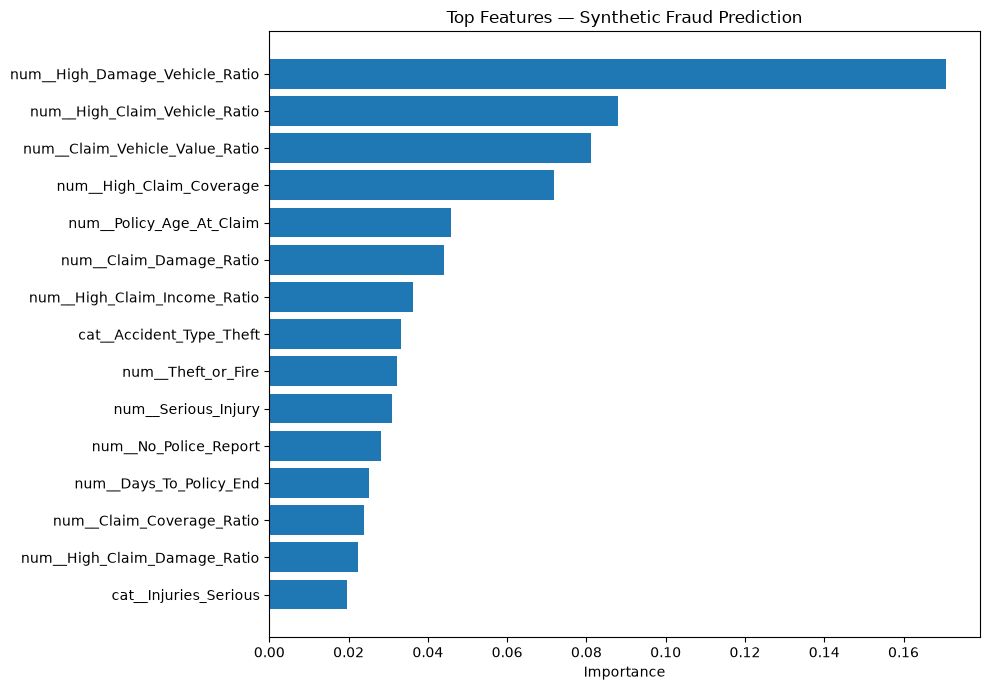

In [262]:
top_features_v2 = (
    xgb_importance_v2
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_v2["Feature"],
    top_features_v2["Importance"]
)

plt.title(
    "Top Features — Synthetic Fraud Prediction"
)

plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [263]:
results_v2_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,1.00,1.00,1.00,1.00,1.00
1,Random Forest,0.99,0.98,0.99,0.99,1.00
2,XGBoost,0.99,0.99,0.99,0.99,1.00
3,Gradient Boosting,0.99,0.99,0.98,0.98,1.00


In [264]:
model_comparison_v2 = results_v2_df.copy()

model_comparison_v2

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,1.00,1.00,1.00,1.00,1.00
1,Random Forest,0.99,0.98,0.99,0.99,1.00
2,XGBoost,0.99,0.99,0.99,0.99,1.00
3,Gradient Boosting,0.99,0.99,0.98,0.98,1.00


## 12. Probabilistic Synthetic Fraud Target

The first synthetic fraud target was deterministic: claims with a risk score
above a fixed threshold were labeled as fraudulent.

This produced near-perfect model performance because the predictors directly
encoded the target-generation rule.

To create a more realistic supervised-learning experiment, a probabilistic
fraud target is generated. Higher risk scores increase the probability of
fraud, but the relationship is not deterministic.

The original target and first synthetic target are retained for comparison.

In [265]:
# Create a probability of fraud based on the risk score

score = fraud_model_df["Synthetic_Fraud_Score"]

fraud_probability = (
    0.05
    + 0.08 * score
)

fraud_probability = fraud_probability.clip(
    lower=0.05,
    upper=0.90
)

fraud_model_df["Synthetic_Fraud_Probability"] = fraud_probability

fraud_model_df[
    [
        "Synthetic_Fraud_Score",
        "Synthetic_Fraud_Probability"
    ]
].head(20)

,Synthetic_Fraud_Score,Synthetic_Fraud_Probability
0,0,0.05
1,2,0.21
2,0,0.05
3,1,0.13
4,0,0.05
5,1,0.13
6,3,0.29
7,1,0.13
8,2,0.21
9,1,0.13


In [266]:
np.random.seed(42)

fraud_model_df["Synthetic_Fraud_Target_V2"] = (
    np.random.random(len(fraud_model_df))
    < fraud_model_df["Synthetic_Fraud_Probability"]
).astype(int)

In [267]:
fraud_model_df["Synthetic_Fraud_Target_V2"].value_counts()

Synthetic_Fraud_Target_V2
0    2348
1     652
Name: count, dtype: int64

In [268]:
fraud_model_df["Synthetic_Fraud_Target_V2"].value_counts(
    normalize=True
) * 100

Synthetic_Fraud_Target_V2
0   78.27
1   21.73
Name: proportion, dtype: float64

In [269]:
fraud_model_df.groupby(
    "Synthetic_Fraud_Score"
)["Synthetic_Fraud_Target_V2"].agg(
    ["count", "mean"]
)

,count,mean
Synthetic_Fraud_Score,,
0,410,0.06
1,878,0.13
2,709,0.20
3,432,0.27
4,276,0.39
5,152,0.39
6,85,0.53
7,43,0.65
8,9,0.78


## 13. Final Fraud Modeling Dataset

The probabilistic synthetic fraud target is used as the final modeling
target.

Intermediate rule-based variables used to generate the target are excluded
from the feature set. The model instead receives the underlying customer,
vehicle, policy, and claim attributes from which those risk signals were
derived.

Identifiers, post-investigation variables, payment information, and target
generation variables are excluded to reduce leakage./

In [271]:
final_feature_columns = [
    # -------------------------
    # Customer
    # -------------------------
    "Gender",
    "Age",
    "Marital_Status",
    "Occupation",
    "Annual_Income",
    "Driving_Experience_Years",

    # -------------------------
    # Vehicle
    # -------------------------
    "Vehicle_Type",
    "Brand",
    "Manufacture_Year",
    "Fuel_Type",
    "Engine_CC",
    "Vehicle_Value",

    # -------------------------
    # Policy
    # -------------------------
    "Policy_Type",
    "Coverage_Amount",
    "Premium_Amount",
    "No_Claim_Bonus",

    # -------------------------
    # Claim
    # -------------------------
    "Accident_City",
    "Accident_Type",
    "Weather_Condition",
    "Police_Report_Filed",
    "Injuries",
    "Estimated_Damage_Cost",
    "Claim_Amount",

    # -------------------------
    # Underlying engineered features
    # -------------------------
    "Vehicle_Age",
    "Premium_Coverage_Ratio",
    "Claim_Damage_Ratio",
    "Claim_Vehicle_Value_Ratio",
    "Claim_Coverage_Ratio",
    "Damage_Vehicle_Value_Ratio",
    "Claim_Income_Ratio",

    # -------------------------
    # Temporal / policy timing
    # -------------------------
    "Claim_Year",
    "Claim_Month",
    "Claim_DayOfWeek",
    "Claim_Weekend",
    "Policy_Age_At_Claim",
    "Days_To_Policy_End"
]

In [272]:
model_df_final = fraud_model_df[
    final_feature_columns + ["Synthetic_Fraud_Target_V2"]
].copy()

In [273]:
X_final = model_df_final.drop(
    columns=["Synthetic_Fraud_Target_V2"]
)

y_final = model_df_final["Synthetic_Fraud_Target_V2"]

In [274]:
print("Dataset shape:", model_df_final.shape)
print("Feature count:", X_final.shape[1])
print("Target count:", y_final.shape[0])

Dataset shape: (3000, 37)
Feature count: 36
Target count: 3000


In [275]:
missing_final = (
    model_df_final
    .isna()
    .sum()
)

missing_final[
    missing_final > 0
]

Series([], dtype: int64)

In [276]:
numeric_features_final = [
    "Age",
    "Annual_Income",
    "Driving_Experience_Years",
    "Manufacture_Year",
    "Engine_CC",
    "Vehicle_Value",
    "Coverage_Amount",
    "Premium_Amount",
    "No_Claim_Bonus",
    "Estimated_Damage_Cost",
    "Claim_Amount",
    "Vehicle_Age",
    "Premium_Coverage_Ratio",
    "Claim_Damage_Ratio",
    "Claim_Vehicle_Value_Ratio",
    "Claim_Coverage_Ratio",
    "Damage_Vehicle_Value_Ratio",
    "Claim_Income_Ratio",
    "Claim_Year",
    "Claim_Month",
    "Claim_DayOfWeek",
    "Claim_Weekend",
    "Policy_Age_At_Claim",
    "Days_To_Policy_End"
]

In [277]:
categorical_features_final = [
    "Gender",
    "Marital_Status",
    "Occupation",
    "Vehicle_Type",
    "Brand",
    "Fuel_Type",
    "Policy_Type",
    "Accident_City",
    "Accident_Type",
    "Weather_Condition",
    "Police_Report_Filed",
    "Injuries"
]

In [278]:
print(
    "Features listed:",
    len(numeric_features_final) +
    len(categorical_features_final)
)

print(
    "Actual features:",
    len(X_final.columns)
)

Features listed: 36
Actual features: 36


In [279]:
preprocessor_final = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_final
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_final
        )
    ],
    remainder="drop"
)

In [280]:
X_train_final, X_test_final, y_train_final, y_test_final = (
    train_test_split(
        X_final,
        y_final,
        test_size=0.20,
        random_state=42,
        stratify=y_final
    )
)

In [281]:
print("Training shape:", X_train_final.shape)
print("Testing shape :", X_test_final.shape)

print("\nOverall fraud rate:")
print(y_final.mean())

print("\nTraining fraud rate:")
print(y_train_final.mean())

print("\nTesting fraud rate:")
print(y_test_final.mean())

Training shape: (2400, 36)
Testing shape : (600, 36)

Overall fraud rate:
0.21733333333333332

Training fraud rate:
0.2175

Testing fraud rate:
0.21666666666666667


In [282]:
models_final = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

In [283]:
trained_models_final = {}
final_results = []

for model_name, model in models_final.items():

    print("=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_final),
            ("model", model)
        ]
    )

    pipeline.fit(
        X_train_final,
        y_train_final
    )

    y_pred = pipeline.predict(
        X_test_final
    )

    y_prob = pipeline.predict_proba(
        X_test_final
    )[:, 1]

    final_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_final,
            y_pred
        ),
        "Precision": precision_score(
            y_test_final,
            y_pred
        ),
        "Recall": recall_score(
            y_test_final,
            y_pred
        ),
        "F1_Score": f1_score(
            y_test_final,
            y_pred
        ),
        "ROC_AUC": roc_auc_score(
            y_test_final,
            y_prob
        )
    })

    trained_models_final[model_name] = pipeline

    print("Training completed.\n")

Training: Logistic Regression
Training completed.

Training: Random Forest
Training completed.

Training: Gradient Boosting
Training completed.

Training: XGBoost
Training completed.



In [284]:
final_results_df = (
    pd.DataFrame(final_results)
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

final_results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest,0.78,0.50,0.06,0.11,0.67
1,Gradient Boosting,0.79,0.52,0.09,0.16,0.66
2,Logistic Regression,0.77,0.29,0.05,0.09,0.63
3,XGBoost,0.77,0.37,0.08,0.13,0.62


## 14. Fraud Probability Threshold Analysis

The default classification threshold of 0.50 is not necessarily optimal
for fraud detection.

The models produce a probability of fraud for each claim. Different
thresholds can be applied to convert these probabilities into binary
fraud/non-fraud predictions.

Thresholds are evaluated using precision, recall, and F1-score.

ROC-AUC is not affected by the classification threshold.

In [285]:
threshold_models = {}

for model_name, model in trained_models_final.items():
    
    probabilities = model.predict_proba(
        X_test_final
    )[:, 1]
    
    threshold_models[model_name] = probabilities

In [286]:
thresholds = np.arange(
    0.10,
    0.61,
    0.02
)

threshold_results = []

for model_name, probabilities in threshold_models.items():

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        threshold_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision_score(
                y_test_final,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test_final,
                predictions,
                zero_division=0
            ),
            "F1_Score": f1_score(
                y_test_final,
                predictions,
                zero_division=0
            ),
            "Accuracy": accuracy_score(
                y_test_final,
                predictions
            )
        })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df.head()

,Model,Threshold,Precision,Recall,F1_Score,Accuracy
0,Logistic Regression,0.10,0.24,0.93,0.39,0.36
1,Logistic Regression,0.12,0.25,0.88,0.39,0.40
2,Logistic Regression,0.14,0.25,0.82,0.39,0.44
3,Logistic Regression,0.16,0.27,0.78,0.40,0.49
4,Logistic Regression,0.18,0.26,0.68,0.38,0.52


In [287]:
best_thresholds = (
    threshold_results_df
    .sort_values(
        ["Model", "F1_Score"],
        ascending=[True, False]
    )
    .groupby("Model")
    .head(1)
)

best_thresholds

,Model,Threshold,Precision,Recall,F1_Score,Accuracy
54,Gradient Boosting,0.14,0.27,0.82,0.41,0.49
3,Logistic Regression,0.16,0.27,0.78,0.40,0.49
31,Random Forest,0.20,0.31,0.78,0.44,0.57
78,XGBoost,0.10,0.27,0.84,0.41,0.48


In [288]:
rf_threshold_results = (
    threshold_results_df[
        threshold_results_df["Model"] == "Random Forest"
    ]
    .sort_values("Threshold")
)

rf_threshold_results

,Model,Threshold,Precision,Recall,F1_Score,Accuracy
26,Random Forest,0.10,0.23,0.96,0.36,0.28
27,Random Forest,0.12,0.23,0.93,0.38,0.33
28,Random Forest,0.14,0.25,0.92,0.39,0.38
29,Random Forest,0.16,0.27,0.85,0.40,0.46
30,Random Forest,0.18,0.28,0.82,0.42,0.52
31,Random Forest,0.20,0.31,0.78,0.44,0.57
32,Random Forest,0.22,0.32,0.68,0.44,0.62
33,Random Forest,0.24,0.33,0.58,0.42,0.65
34,Random Forest,0.26,0.35,0.54,0.42,0.68
35,Random Forest,0.28,0.34,0.42,0.38,0.70


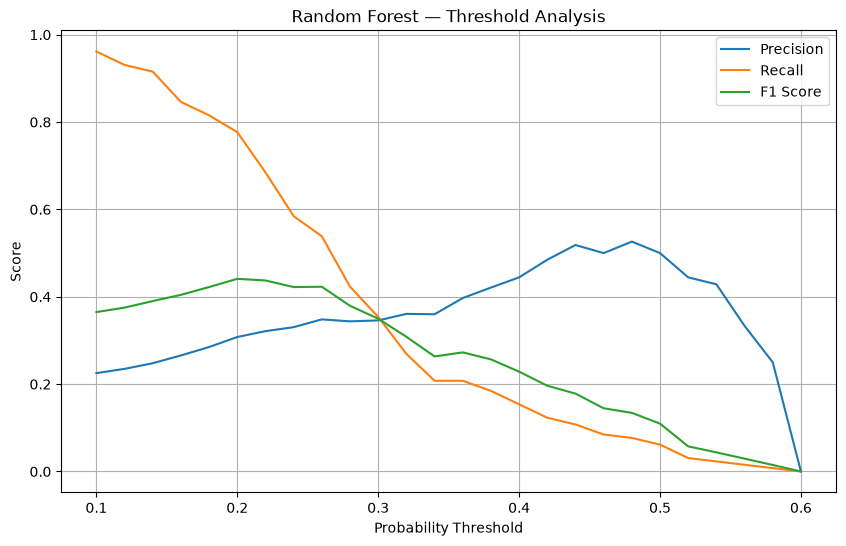

In [289]:
plt.figure(figsize=(10, 6))

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["F1_Score"],
    label="F1 Score"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Random Forest — Threshold Analysis")
plt.legend()
plt.grid(True)
plt.show()

In [290]:
rf_best_row = (
    best_thresholds[
        best_thresholds["Model"] == "Random Forest"
    ]
    .iloc[0]
)

rf_best_threshold = rf_best_row["Threshold"]

print(
    "Random Forest optimal F1 threshold:",
    rf_best_threshold
)

Random Forest optimal F1 threshold: 0.2


In [291]:
rf_probabilities = threshold_models["Random Forest"]

rf_final_predictions = (
    rf_probabilities >= rf_best_threshold
).astype(int)

print(
    classification_report(
        y_test_final,
        rf_final_predictions,
        target_names=[
            "Not Fraud",
            "Fraud"
        ]
    )
)

              precision    recall  f1-score   support

   Not Fraud       0.89      0.52      0.65       470
       Fraud       0.31      0.78      0.44       130

    accuracy                           0.57       600
   macro avg       0.60      0.65      0.55       600
weighted avg       0.77      0.57      0.61       600



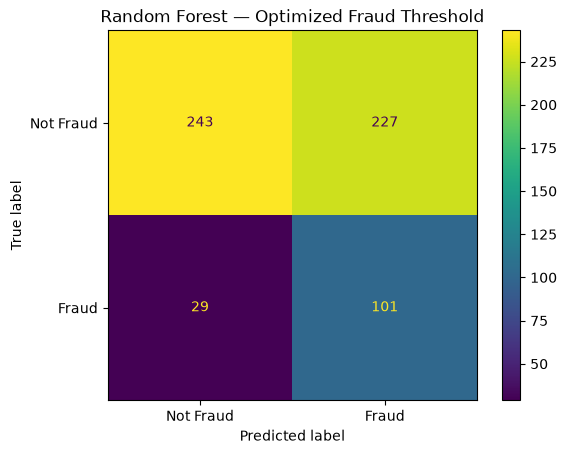

In [292]:
rf_final_cm = confusion_matrix(
    y_test_final,
    rf_final_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_final_cm,
    display_labels=[
        "Not Fraud",
        "Fraud"
    ]
)

disp.plot()

plt.title(
    "Random Forest — Optimized Fraud Threshold"
)

plt.show()

In [293]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

In [294]:
rf_final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_final),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [295]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [296]:
rf_oof_probabilities = cross_val_predict(
    rf_final_pipeline,
    X_train_final,
    y_train_final,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [297]:
thresholds = np.arange(
    0.05,
    0.61,
    0.01
)

oof_threshold_results = []

for threshold in thresholds:

    oof_predictions = (
        rf_oof_probabilities >= threshold
    ).astype(int)

    oof_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train_final,
            oof_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train_final,
            oof_predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_train_final,
            oof_predictions,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_train_final,
            oof_predictions
        )
    })

oof_threshold_df = pd.DataFrame(
    oof_threshold_results
)

In [298]:
best_oof_threshold_row = (
    oof_threshold_df
    .sort_values("F1_Score", ascending=False)
    .iloc[0]
)

best_oof_threshold_row

Threshold   0.20
Precision   0.28
Recall      0.70
F1_Score    0.40
Accuracy    0.54
Name: 15, dtype: float64

In [299]:
final_threshold = (
    best_oof_threshold_row["Threshold"]
)

print(
    f"Selected threshold: {final_threshold:.2f}"
)

Selected threshold: 0.20


In [300]:
rf_final_pipeline.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['Gender','Age','Marital_Status',...,'Claim_Weekend','Policy_Age_At_Claim', 'Days_To_Policy_End']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [301]:
rf_test_probabilities = (
    rf_final_pipeline
    .predict_proba(X_test_final)[:, 1]
)

In [302]:
rf_test_predictions = (
    rf_test_probabilities >= final_threshold
).astype(int)

In [303]:
print(
    classification_report(
        y_test_final,
        rf_test_predictions,
        target_names=[
            "Not Fraud",
            "Fraud"
        ]
    )
)

              precision    recall  f1-score   support

   Not Fraud       0.89      0.52      0.65       470
       Fraud       0.31      0.78      0.44       130

    accuracy                           0.57       600
   macro avg       0.60      0.65      0.55       600
weighted avg       0.77      0.57      0.61       600



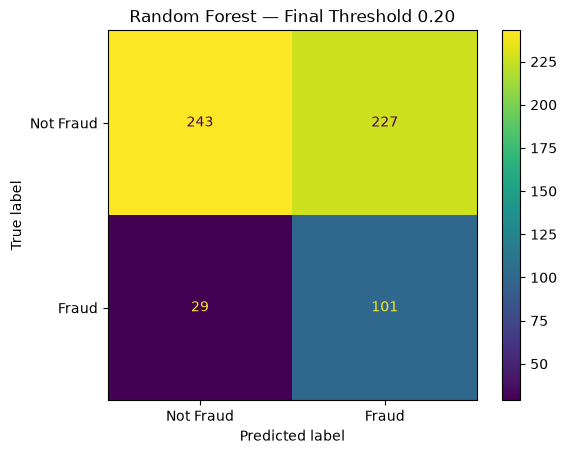

In [304]:
final_cm = confusion_matrix(
    y_test_final,
    rf_test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=[
        "Not Fraud",
        "Fraud"
    ]
)

disp.plot()

plt.title(
    f"Random Forest — Final Threshold {final_threshold:.2f}"
)

plt.show()

In [305]:
final_model_metrics = {
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(
        y_test_final,
        rf_test_predictions
    ),
    "Precision": precision_score(
        y_test_final,
        rf_test_predictions
    ),
    "Recall": recall_score(
        y_test_final,
        rf_test_predictions
    ),
    "F1_Score": f1_score(
        y_test_final,
        rf_test_predictions
    ),
    "ROC_AUC": roc_auc_score(
        y_test_final,
        rf_test_probabilities
    )
}

pd.DataFrame(
    [final_model_metrics]
)

,Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,0.20,0.57,0.31,0.78,0.44,0.67


In [306]:
best_oof_threshold_row

Threshold   0.20
Precision   0.28
Recall      0.70
F1_Score    0.40
Accuracy    0.54
Name: 15, dtype: float64

## 16. Final Fraud Model

The Random Forest pipeline is selected for deployment because it provides
the strongest ROC-AUC among the evaluated models and supports a useful
recall-oriented probability threshold.

The selected classification threshold is 0.20.

The complete preprocessing and modeling pipeline is saved so that the
Streamlit application can apply exactly the same transformations used
during model training.

In [308]:
from pathlib import Path

MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Model directory:", MODEL_DIR)

Model directory: C:\Users\adity\Documents\autoshield-insurance-analytics\models


In [309]:
import joblib

MODEL_PATH = MODEL_DIR / "fraud_detection_pipeline.joblib"

joblib.dump(
    rf_final_pipeline,
    MODEL_PATH
)

print(
    f"Model saved successfully:\n{MODEL_PATH}"
)

Model saved successfully:
C:\Users\adity\Documents\autoshield-insurance-analytics\models\fraud_detection_pipeline.joblib


In [310]:
model_metadata = {
    "model_name": "Random Forest",
    "target": "Synthetic_Fraud_Target_V2",
    "classification_threshold": float(final_threshold),
    "roc_auc": float(final_model_metrics["ROC_AUC"]),
    "accuracy": float(final_model_metrics["Accuracy"]),
    "precision": float(final_model_metrics["Precision"]),
    "recall": float(final_model_metrics["Recall"]),
    "f1_score": float(final_model_metrics["F1_Score"])
}

In [311]:
import json

METADATA_PATH = MODEL_DIR / "model_metadata.json"

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_metadata,
        file,
        indent=4
    )

print(
    f"Metadata saved successfully:\n{METADATA_PATH}"
)

Metadata saved successfully:
C:\Users\adity\Documents\autoshield-insurance-analytics\models\model_metadata.json


In [312]:
FEATURE_SCHEMA_PATH = MODEL_DIR / "feature_schema.json"

feature_schema = {
    "numeric_features": numeric_features_final,
    "categorical_features": categorical_features_final,
    "all_features": final_feature_columns
}

with open(
    FEATURE_SCHEMA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        feature_schema,
        file,
        indent=4
    )

print(
    f"Feature schema saved successfully:\n{FEATURE_SCHEMA_PATH}"
)

Feature schema saved successfully:
C:\Users\adity\Documents\autoshield-insurance-analytics\models\feature_schema.json


In [313]:
loaded_model = joblib.load(
    MODEL_PATH
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [314]:
loaded_probabilities = loaded_model.predict_proba(
    X_test_final
)[:, 1]

In [315]:
loaded_predictions = (
    loaded_probabilities >= final_threshold
).astype(int)

In [316]:
print(
    classification_report(
        y_test_final,
        loaded_predictions,
        target_names=[
            "Not Fraud",
            "Fraud"
        ]
    )
)

              precision    recall  f1-score   support

   Not Fraud       0.89      0.52      0.65       470
       Fraud       0.31      0.78      0.44       130

    accuracy                           0.57       600
   macro avg       0.60      0.65      0.55       600
weighted avg       0.77      0.57      0.61       600



In [317]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_final,
        loaded_probabilities
    )
)

ROC-AUC: 0.6748281505728314
